# Assignment 2: Transformer Fine-tuning for Sentence Factuality Classification of the Brazilian Portuguese FactNews Dataset

**Dataset:** FactNews (Vargas et al., 2023) - 6191 sentences; 3 classes: Factual, Quote, Bias

**Goals:**
- Fine-tune HuggingFace transformer models (BERTimbau, XLM-RoBERTa) for the sentence-level factuality classification task.
- Explore pre-trained models for the same language and/or genre. 
- Compare transformer performance with Assignment 1 (traditional Machine Learning).
- Additionally, implement parameter-efficient fine-tuning with LoRA and compare weighted loss vs undersampling for class imbalance handling

## Assignment 1 Recap & Baseline Results

| System | Type | Feature | Macro-F1 |
|--------|------|---------|----------|
| Random baseline | Baseline | — | 0.333 |
| FastText + LR (imbalanced) | Traditional ML | FastText | 0.4808 |
| TF-IDF (imbalanced) | Traditional ML | TF-IDF | 0.5707 |
| **Naive Bayes + Bag of Words (A1 best)** | **Traditional ML** | **BoW** | **0.6264** |
| TF-IDF + SVM (Vargas et al.) | Literature | TF-IDF | 0.6600 |
| mBERT fine-tuned (Vargas et al.) | Literature SOTA | mBERT | 0.8800 |

**Key findings from Assignment 1:**
- Sparse representations (BoW) outperformed dense (FastText) for this task
- **Bias/Factual** is the primary confusion pattern across all models
- Class imbalance (only 9% of Biased sentences) is the core challenge
- Undersampling improved Bias recall at a small Macro-F1 cost
- Limitations: stemming degrades embeddings; FastText loses sentence structure; no deep learning by design

**What carries over to Assignment 2:**
- Same dataset: FactNews CSV (`factnews_dataset.csv`)
- Same primary metric: Macro-F1
- Same class mapping: `classe` column with {-1: Quote, 0: Factual, 1: Bias}

**What changes:**
- No RSLP stemming or Portuguese stop word removal --> transformers use subword tokenization
- No BoW/TF-IDF feature extraction --> transformers learn representations end-to-end
- Label remapping: `{-1, 0, 1}` --> `{0, 1, 2}` for HuggingFace compatibility
- Class imbalance: `class_weight='balanced'` --> weighted cross-entropy loss in custom Trainer
- LoRA for parameter-efficient fine-tuning

## 1. Tool Setup

All necessary libraries are imported below with role annotations.
Global seeds are set for **full reproducibility** across PyTorch, NumPy, and Python's random module.

In [ ]:
import os, random, warnings, time
warnings.filterwarnings('ignore')
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# Data manipulation
import numpy  as np   
import pandas as pd   

import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt   
import matplotlib.ticker as mticker
import seaborn           as sns   

# PyTorch
import torch                      
import torch.nn as nn             

# HuggingFace Transformers
from transformers import (
    AutoTokenizer,                          
    AutoModelForSequenceClassification,     
    TrainingArguments,                       
    Trainer,                                 
    DataCollatorWithPadding,                
)
from datasets import Dataset, DatasetDict   

from peft import get_peft_model, LoraConfig, TaskType  

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay,
)

os.environ["TRANSFORMERS_CACHE"] = "/kaggle/working/hf_cache"
os.environ["HF_HOME"] = "/kaggle/working/hf_cache"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    DEVICE = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("Using MAC GPU")
else:
    DEVICE = torch.device('cpu')
    print("Using CPU — training will be significantly slower")

sns.set_theme(style='whitegrid', palette='viridis', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', 200)

import transformers, datasets, peft, sklearn
print(f"\nLibrary versions:")
print(f"  torch:        {torch.__version__}")
print(f"  transformers: {transformers.__version__}")
print(f"  datasets:     {datasets.__version__}")
print(f"  peft:         {peft.__version__}")
print(f"  sklearn:      {sklearn.__version__}")

Using GPU: Tesla T4

Library versions:
  torch:        2.10.0+cu128
  transformers: 5.0.0
  datasets:     4.8.3
  peft:         0.18.1
  sklearn:      1.6.1


## 2. Data Loading Preparation

**Critical step: Label Remapping**

HuggingFace models require labels in `[0, N-1]`. The original FactNews labels are `{-1, 0, 1}`, which **must** be remapped:

| Original | Remapped | Class |
|----------|----------|-------|
| -1       | 0        | Quote |
| 0        | 1        | Factual |
| 1        | 2        | Bias |


In [ ]:
# Load dataset
DATA_PATH = 'Dataset/franciellevargas-FactNews-786c504/dataset/factnews_dataset.csv'  # Change this path if necessary
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Remap labels: {-1, 0, 1} → {0, 1, 2}
LABEL_REMAP = {-1: 0, 0: 1, 1: 2}
df['label'] = df['classe'].map(LABEL_REMAP)

# Human-readable mappings for model config
id2label = {0: 'Quote', 1: 'Factual', 2: 'Bias'}
label2id = {'Quote': 0, 'Factual': 1, 'Bias': 2}

print(f"\nLabel mapping applied:")
for orig, new in LABEL_REMAP.items():
    print(f"  classe={orig:+d} → label={new} ({id2label[new]})")

# Ensure there is no NaN labels
assert df['label'].isna().sum() == 0, "Label remapping produced NaN values!"
print(f"\nAll {len(df)} labels remapped successfully.")
df[['sentences', 'classe', 'label']].head()

Dataset shape: 6191 rows × 7 columns

Label mapping applied:
  classe=-1 → label=0 (Quote)
  classe=+0 → label=1 (Factual)
  classe=+1 → label=2 (Bias)

All 6191 labels remapped successfully.


,sentences,classe,label
0,"""Não houve sobreviventes"", disse Okala.",-1,0
1,As vítimas do acidente foram 14 passageiros e três membros da tripulação.,0,1
2,"O avião explodiu e se incendiou, acrescentou o porta-voz da ONU em Kinshasa, Jean-Tobias Okala.",0,1
3,"O porta-voz informou que o avião, um Soviet Antonov-28 de fabricação ucraniana e propriedade de uma companhia congolesa, a Trasept Congo, também levava uma carga de minerais.",0,1
4,"Segundo fontes aeroportuárias, os membros da tripulação eram de nacionalidade russa.",0,1


In [ ]:
# Stratified 80/20 split; same as Assignment 1
X_text = df['sentences'].values
y = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=SEED, stratify=y
)

# Verify class distribution 
print("Class distribution in splits:")
print(f"{'Class':<10} {'Train':>8} {'%':>6}   {'Test':>8} {'%':>6}")
print("-" * 45)
for cls_id in sorted(set(y)):
    n_tr = (y_train == cls_id).sum()
    n_te = (y_test == cls_id).sum()
    print(f"{id2label[cls_id]:<10} {n_tr:>8} {100*n_tr/len(y_train):>5.1f}%   {n_te:>8} {100*n_te/len(y_test):>5.1f}%")
print(f"{'Total':<10} {len(y_train):>8}          {len(y_test):>8}")

Class distribution in splits:
Class         Train      %       Test      %
---------------------------------------------
Quote          1113  22.5%        278  22.4%
Factual        3393  68.5%        849  68.5%
Bias            446   9.0%        112   9.0%
Total          4952              1239


## 3. Model Selection & Justification

### 3.1 - Model Candidates

We evaluate two transformer models for fine-tuning, plus reference baselines:

| Model | HuggingFace ID | Type | Language | Why relevant |
|-------|---------------|------|----------|-------------|
| **BERTimbau** (primary) | `neuralmind/bert-base-portuguese-cased` | Transformer (BERT) | Portuguese (BR) | Monolingual PT - best linguistic fit. Same architecture family as Vargas et al. (2023) mBERT baseline. |
| **XLM-RoBERTa** (secondary) | `FacebookAI/xlm-roberta-base` | Transformer (RoBERTa) | 100 languages | Strong multilingual baseline - tests whether multilingual pre-training competes with monolingual. |

**Why BERTimbau is the primary model:**
1. Pre-trained specifically on **Brazilian Portuguese** text (Wikipedia + BrWaC corpus)
2. Handles Portuguese morphology and syntax **natively** - no multilingual generalisation needed
3. Vargas et al. (2023) achieved **0.88 Macro-F1** with mBERT - BERTimbau should match or exceed this given monolingual advantage

In [4]:
# Define model names
BERTIMBAU_MODEL = "neuralmind/bert-base-portuguese-cased"
XLMR_MODEL      = "FacebookAI/xlm-roberta-base"

print(f"Primary model:   {BERTIMBAU_MODEL}")
print(f"Secondary model: {XLMR_MODEL}")

Primary model:   neuralmind/bert-base-portuguese-cased
Secondary model: FacebookAI/xlm-roberta-base


## 4. Tokenization

**No traditional preprocessing for transformers**

In Assignment 1, we applied RSLP stemming, Portuguese stop word removal, and diacritic-aware regex cleaning before feeding text to BoW/TF-IDF models.

For transformer models, we do **NOT** apply any of these preprocessing steps because:
- Transformers use their own **subword tokenization** (WordPiece for BERT, SentencePiece for XLM-R)
- Subword tokenizers handle out-of-vocabulary words by splitting them into known subunits
- Stemming would **destroy** morphological information that BERT has learned to leverage
- Stop words carry syntactic information that is valuable to attention mechanisms
- The raw, unprocessed text is the optimal input for fine-tuning

In [5]:
# Load tokenizers
tokenizer_bert = AutoTokenizer.from_pretrained(BERTIMBAU_MODEL, do_lower_case=False)
tokenizer_xlmr = AutoTokenizer.from_pretrained(XLMR_MODEL)

# Tokenization examples on Portuguese sentences
examples = [
    'O presidente disse que a economia está crescendo.',       # Factual-like
    '"A situação é gravíssima", afirmou o ministro.',          # Quote-like
    'O governo incompetente destruiu completamente o país.',   # Bias-like
]

print("BERTimbau Tokenization Examples:")
for sent in examples:
    tokens = tokenizer_bert.tokenize(sent)
    print(f"  Input:  {sent}")
    print(f"  Tokens: {tokens}")
    print(f"  Count:  {len(tokens)}")
    print()

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERTimbau Tokenization Examples:
  Input:  O presidente disse que a economia está crescendo.
  Tokens: ['O', 'presidente', 'disse', 'que', 'a', 'economia', 'está', 'crescendo', '.']
  Count:  9

  Input:  "A situação é gravíssima", afirmou o ministro.
  Tokens: ['"', 'A', 'situação', 'é', 'grav', '##íssima', '"', ',', 'afirmou', 'o', 'ministro', '.']
  Count:  12

  Input:  O governo incompetente destruiu completamente o país.
  Tokens: ['O', 'governo', 'incomp', '##et', '##ente', 'destruiu', 'completamente', 'o', 'país', '.']
  Count:  10



#### Token length distribution across the dataset

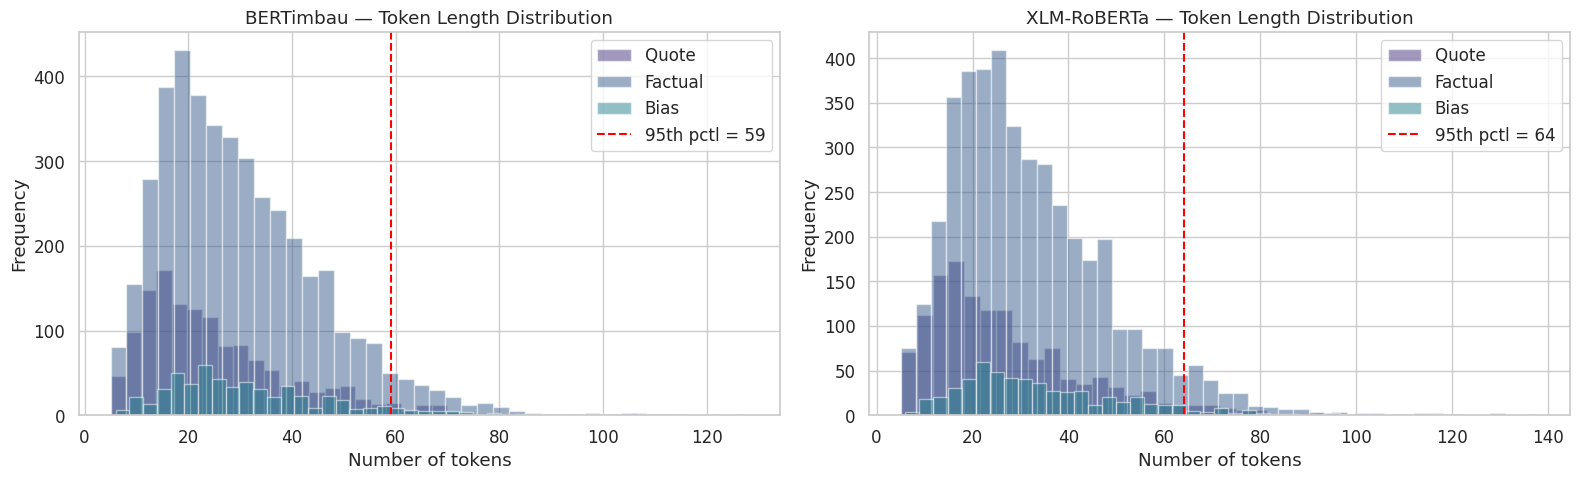


Optimal max_length: 64 tokens
  (95th percentile of BERTimbau token lengths, rounded to multiple of 8)
  Sentences truncated: 210 / 6191 (3.4%)


In [ ]:
# Tokenise ALL sentences to determine optimal max_length
bert_lengths = [len(tokenizer_bert.encode(s)) for s in df['sentences']]
xlmr_lengths = [len(tokenizer_xlmr.encode(s)) for s in df['sentences']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, lengths, name in [(axes[0], bert_lengths, 'BERTimbau'), (axes[1], xlmr_lengths, 'XLM-RoBERTa')]:
    for cls_id, cls_name in id2label.items():
        mask = df['label'] == cls_id
        cls_lens = [lengths[i] for i in range(len(lengths)) if mask.iloc[i]]
        ax.hist(cls_lens, bins=40, alpha=0.5, label=cls_name)
    p95 = int(np.percentile(lengths, 95))
    ax.axvline(p95, color='red', linestyle='--', label=f'95th pctl = {p95}')
    ax.set_title(f'{name} - Token Length Distribution')
    ax.set_xlabel('Number of tokens')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()

MAX_LENGTH = int(np.percentile(bert_lengths, 95))   # Determine max_length
MAX_LENGTH = min(((MAX_LENGTH + 7) // 8) * 8, 512)  # Round up to nearest multiple of 8 for GPU efficiency

print(f"\nOptimal max_length: {MAX_LENGTH} tokens")
print(f"(95th percentile of BERTimbau token lengths, rounded to multiple of 8)")
print(f"Sentences truncated: {sum(1 for l in bert_lengths if l > MAX_LENGTH)} / {len(bert_lengths)} ({100*sum(1 for l in bert_lengths if l > MAX_LENGTH)/len(bert_lengths):.1f}%)")

In [7]:
# Create HuggingFace Datasets
train_df = pd.DataFrame({'text': X_train_text, 'label': y_train})
test_df  = pd.DataFrame({'text': X_test_text,  'label': y_test})

ds_train = Dataset.from_pandas(train_df, preserve_index=False)
ds_test  = Dataset.from_pandas(test_df,  preserve_index=False)

print(f"Train dataset: {ds_train}")
print(f"Test dataset:  {ds_test}")

Train dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 4952
})
Test dataset:  Dataset({
    features: ['text', 'label'],
    num_rows: 1239
})


In [8]:
# Tokenization function
def tokenize_fn(batch, tokenizer):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

# Tokenise for BERTimbau
ds_train_bert = ds_train.map(lambda b: tokenize_fn(b, tokenizer_bert), batched=True, keep_in_memory=True)
ds_test_bert  = ds_test.map(lambda b: tokenize_fn(b, tokenizer_bert), batched=True, keep_in_memory=True)

# Tokenise for XLM-RoBERTa 
ds_train_xlmr = ds_train.map(lambda b: tokenize_fn(b, tokenizer_xlmr), batched=True, keep_in_memory=True)
ds_test_xlmr  = ds_test.map(lambda b: tokenize_fn(b, tokenizer_xlmr), batched=True, keep_in_memory=True)

# Show tokenized example
print("Example tokenized sample (BERTimbau):")
ex = ds_train_bert[0]
print(f"  Text:           {ex['text'][:100]}...")
print(f"  input_ids:      {ex['input_ids'][:10]}... (len={len(ex['input_ids'])})")
print(f"  attention_mask: {ex['attention_mask'][:10]}... (len={len(ex['attention_mask'])})")
print(f"  label:          {ex['label']} ({id2label[ex['label']]})")

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Example tokenized sample (BERTimbau):
  Text:           Milhares se aglomeram diante do Palácio de Buckingham para se despedir da rainha, que ocupou o trono...
  input_ids:      [101, 2209, 5549, 176, 11621, 288, 4271, 171, 4976, 125]... (len=36)
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]... (len=36)
  label:          1 (Factual)


## 5. Handling Class Imbalance for Fine-tuning

In Assignment 1, we used `class_weight='balanced'` and undersampling (~446 per class). For transformers, the equivalent strategies are:

| Strategy | How | Trade-off |
|----------|-----|-----------|
| **Weighted CE loss** | Custom Trainer overriding `compute_loss` | Clean, no data modification |
| **Undersampling** | Match A1 approach | Loses training data |
| Oversampling | Duplicate minority samples | Risk of overfitting |

We implemented **both** weighted loss and undersampling for direct comparison with Assignment 1.

In [9]:
# Compute class weights from training distribution
from collections import Counter
class_counts = Counter(y_train)
n_samples = len(y_train)
n_classes = len(class_counts)

class_weights = {cls: n_samples / (n_classes * count) for cls, count in class_counts.items()}
weight_tensor = torch.tensor([class_weights[i] for i in range(n_classes)], dtype=torch.float32)

print("Class weights (inverse frequency):")
for cls_id, w in class_weights.items():
    print(f"  {id2label[cls_id]:8s}: {w:.4f}  (n={class_counts[cls_id]})")

Class weights (inverse frequency):
  Factual : 0.4865  (n=3393)
  Quote   : 1.4831  (n=1113)
  Bias    : 3.7010  (n=446)


In [10]:
# WeightedTrainer: overrides compute_loss with class weights
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            self.class_weights = class_weights.to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if self.class_weights is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        else:
            loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("WeightedTrainer defined.")

WeightedTrainer defined.


In [11]:
# Prepare undersampled dataset
min_class_count = min(class_counts.values())
print(f"Undersampling all classes to {min_class_count} samples (smallest class: Bias)")

undersampled_indices = []
for cls_id in range(n_classes):
    cls_indices = np.where(y_train == cls_id)[0]
    sampled = np.random.RandomState(SEED).choice(cls_indices, size=min_class_count, replace=False)
    undersampled_indices.extend(sampled)

np.random.RandomState(SEED).shuffle(undersampled_indices)
X_train_under = X_train_text[undersampled_indices]
y_train_under = y_train[undersampled_indices]

train_under_df = pd.DataFrame({'text': X_train_under, 'label': y_train_under})
ds_train_under = Dataset.from_pandas(train_under_df, preserve_index=False)

# Tokenise undersampled datasets
ds_train_under_bert = ds_train_under.map(lambda b: tokenize_fn(b, tokenizer_bert), batched=True, keep_in_memory=True)
ds_train_under_xlmr = ds_train_under.map(lambda b: tokenize_fn(b, tokenizer_xlmr), batched=True, keep_in_memory=True)

print(f"Undersampled training set: {len(ds_train_under)} samples")
print(f"  Per class: {Counter(y_train_under)}")

Undersampling all classes to 446 samples (smallest class: Bias)


Map:   0%|          | 0/1338 [00:00<?, ? examples/s]

Map:   0%|          | 0/1338 [00:00<?, ? examples/s]

Undersampled training set: 1338 samples
  Per class: Counter({np.int64(1): 446, np.int64(2): 446, np.int64(0): 446})


## 6. Model Fine-tuning

### 6.1 - Training Configuration

Hyperparameters are chosen following standard BERT fine-tuning practices, adapted for our small dataset (6 191 sentences).

In [ ]:
# Training Arguments
def get_training_args(output_dir, epochs=10):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,               # Small dataset -> more epochs needed
        per_device_train_batch_size=8,         # Lowered to fit XLM-R's large embedding layer
        gradient_accumulation_steps=2,         # Simulates batch 16 (8x2) without using extra GPU memory
        per_device_eval_batch_size=16,         # Lowered from 32 just in case evaluation hits the computational limit
        learning_rate=2e-5,                    # Standard BERT fine-tuning LR
        warmup_ratio=0.1,                      # 10% warmup prevents early instability
        weight_decay=0.01,                     # L2 regularisation
        eval_strategy="epoch",                 # Evaluate after each epoch
        save_strategy="best",
        save_total_limit=1,                    # Keep only 2 best checkpoints
        load_best_model_at_end=True,
        metric_for_best_model="eval_macro_f1", # Select best by Macro-F1
        greater_is_better=True,
        logging_steps=50,
        seed=SEED,
        fp16=torch.cuda.is_available(),        # Mixed precision on GPU
        report_to="none",                      # Disable W&B/MLflow
    )

print("Training configuration defined.")

Training configuration defined.


### 6.2 - Evaluation Metrics

We defined a `compute_metrics` function returning Macro-F1 as the primary metric, consistent with Assignment 1.

In [13]:
# Evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':        accuracy_score(labels, preds),
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0),
        'macro_recall':    recall_score(labels, preds, average='macro', zero_division=0),
        'macro_f1':        f1_score(labels, preds, average='macro', zero_division=0),
    }

print("compute_metrics defined (primary: macro_f1).")

compute_metrics defined (primary: macro_f1).


### 6.3 - BERTimbau Fine-tuning

We fine-tuned BERTimbau in **two configurations** for comparison:
1. **Weighted Loss** - uses all training data with class-weighted cross-entropy
2. **Undersampled** - balanced dataset (~446 per class), standard cross-entropy loss

In [ ]:
# Helper: train and return results
ALL_RESULTS = {}  # stores {model_name: {metric: value}}

def train_and_evaluate(model_name_str, hf_model_id, tokenizer, ds_tr, ds_te, use_weighted=True, epochs=10):
    """Fine-tune a model and return test metrics."""
    print(f"\n{'='*70}")
    print(f"  Training: {model_name_str}")
    print(f"{'='*70}")

    # Load fresh model
    model = AutoModelForSequenceClassification.from_pretrained(
        hf_model_id, num_labels=3, id2label=id2label, label2id=label2id
    )

    args = get_training_args(output_dir=f"./results/{model_name_str.replace(' ', '_')}", epochs=epochs)
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    if use_weighted:
        trainer = WeightedTrainer(
            class_weights=weight_tensor,
            model=model, args=args,
            train_dataset=ds_tr, eval_dataset=ds_te,
            processing_class=tokenizer, data_collator=collator,
            compute_metrics=compute_metrics,
        )
    else:
        trainer = Trainer(
            model=model, args=args,
            train_dataset=ds_tr, eval_dataset=ds_te,
            processing_class=tokenizer, data_collator=collator,
            compute_metrics=compute_metrics,
        )

    start = time.time()
    trainer.train()
    train_time = time.time() - start

    # Evaluate on test set
    results = trainer.evaluate(ds_te)
    preds_output = trainer.predict(ds_te)
    y_pred = np.argmax(preds_output.predictions, axis=-1)

    macro_f1 = f1_score(ds_te['label'], y_pred, average='macro')
    print(f"\n  Test Macro-F1: {macro_f1:.4f}  (train time: {train_time:.0f}s)")

    # Store results
    ALL_RESULTS[model_name_str] = {
        'Macro-F1': macro_f1,
        'Accuracy': accuracy_score(ds_te['label'], y_pred),
        'Macro-Precision': precision_score(ds_te['label'], y_pred, average='macro'),
        'Macro-Recall': recall_score(ds_te['label'], y_pred, average='macro'),
        'Train Time (s)': train_time,
        'y_pred': y_pred,
    }

    # Classification report
    target_names = [id2label[i] for i in range(3)]
    print(f"\n{classification_report(ds_te['label'], y_pred, target_names=target_names)}")

    # Training history for loss curves
    history = trainer.state.log_history
    return trainer, model, history

print("train_and_evaluate helper defined.")

train_and_evaluate helper defined.


In [ ]:
# BERTimbau + Weighted Loss
trainer_bert_w, model_bert_w, hist_bert_w = train_and_evaluate(
    "BERTimbau (weighted)", BERTIMBAU_MODEL, tokenizer_bert,
    ds_train_bert, ds_test_bert, use_weighted=True, epochs=10
)


  Training: BERTimbau (weighted)


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.8124  (train time: 581s)

              precision    recall  f1-score   support

       Quote       0.91      0.89      0.90       278
     Factual       0.92      0.95      0.93       849
        Bias       0.70      0.54      0.61       112

    accuracy                           0.90      1239
   macro avg       0.84      0.79      0.81      1239
weighted avg       0.89      0.90      0.90      1239



In [ ]:
# BERTimbau + Undersampled
trainer_bert_u, model_bert_u, hist_bert_u = train_and_evaluate(
    "BERTimbau (undersampled)", BERTIMBAU_MODEL, tokenizer_bert,
    ds_train_under_bert, ds_test_bert, use_weighted=False, epochs=10
)


  Training: BERTimbau (undersampled)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,No log,1.819197,0.760291,0.660558,0.700512,0.663802
2,4.130098,0.958141,0.815981,0.715880,0.807812,0.740424
3,2.169456,1.002413,0.795803,0.722109,0.830613,0.734786
4,1.036335,0.916622,0.832930,0.745899,0.843506,0.766670
5,0.525772,1.097634,0.824052,0.738185,0.843384,0.759270
6,0.255972,1.221290,0.844229,0.749488,0.848032,0.775781
7,0.255972,1.153455,0.871671,0.774283,0.842489,0.799362
8,0.126010,1.333390,0.861985,0.766182,0.853279,0.792973
9,0.041196,1.450427,0.853914,0.753063,0.850802,0.784714
10,0.039846,1.437471,0.857950,0.757341,0.852765,0.788766


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.7888  (train time: 195s)

              precision    recall  f1-score   support

       Quote       0.85      0.93      0.89       278
     Factual       0.97      0.84      0.90       849
        Bias       0.46      0.79      0.58       112

    accuracy                           0.86      1239
   macro avg       0.76      0.85      0.79      1239
weighted avg       0.89      0.86      0.87      1239



### 6.4 - XLM-RoBERTa Fine-tuning

As with BERTimbau, we fine-tuned XLM-RoBERTa in two configurations: **Weighted Loss** and **Undersampled**

In [ ]:
# XLM-RoBERTa + Weighted Loss
trainer_xlmr_w, model_xlmr_w, hist_xlmr_w = train_and_evaluate(
    "XLM-RoBERTa (weighted)", XLMR_MODEL, tokenizer_xlmr,
    ds_train_xlmr, ds_test_xlmr, use_weighted=True, epochs=10
)


  Training: XLM-RoBERTa (weighted)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,1.729183,0.653216,0.730428,0.635475,0.732593,0.650064
2,1.099229,0.601919,0.873285,0.772264,0.771592,0.771554
3,0.798065,0.500536,0.831316,0.741622,0.816407,0.755932
4,0.784301,0.502640,0.855529,0.747006,0.824616,0.775822
5,0.538181,0.630820,0.872478,0.772853,0.825768,0.792563
6,0.284110,0.947949,0.887006,0.793408,0.792140,0.792335
7,0.231878,1.098555,0.887813,0.795439,0.773477,0.781980
8,0.251835,1.332840,0.888620,0.800544,0.762251,0.778076
9,0.086640,1.438149,0.890234,0.807421,0.761423,0.780394
10,0.119339,1.363454,0.888620,0.806083,0.764999,0.782345


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.7823  (train time: 1102s)

              precision    recall  f1-score   support

       Quote       0.90      0.88      0.89       278
     Factual       0.91      0.95      0.93       849
        Bias       0.60      0.46      0.53       112

    accuracy                           0.89      1239
   macro avg       0.81      0.76      0.78      1239
weighted avg       0.88      0.89      0.88      1239



In [ ]:
# XLM-RoBERTa + Undersampled
trainer_xlmr_u, model_xlmr_u, hist_xlmr_u = train_and_evaluate(
    "XLM-RoBERTa (undersampled)", XLMR_MODEL, tokenizer_xlmr,
    ds_train_under_xlmr, ds_test_xlmr, use_weighted=False, epochs=10
)


  Training: XLM-RoBERTa (undersampled)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,No log,2.175398,0.360775,0.449407,0.498251,0.351663
2,4.421823,1.232399,0.792575,0.688385,0.728313,0.695089
3,3.354252,1.196933,0.728814,0.687752,0.768486,0.675710
4,2.026100,1.293435,0.737692,0.704926,0.771685,0.684437
5,1.525936,0.883009,0.845036,0.749668,0.803712,0.761549
6,1.097811,1.278178,0.786118,0.709746,0.807652,0.720709
7,1.097811,1.324933,0.792575,0.714514,0.816124,0.726997
8,0.751014,1.693958,0.761905,0.705738,0.809598,0.707945
9,0.585704,1.404392,0.814366,0.726412,0.814614,0.742518
10,0.473924,1.713096,0.786925,0.717981,0.818379,0.726693


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.7267  (train time: 356s)

              precision    recall  f1-score   support

       Quote       0.89      0.92      0.91       278
     Factual       0.96      0.74      0.84       849
        Bias       0.30      0.79      0.44       112

    accuracy                           0.79      1239
   macro avg       0.72      0.82      0.73      1239
weighted avg       0.88      0.79      0.82      1239



### 6.5 - Training Loss Curves

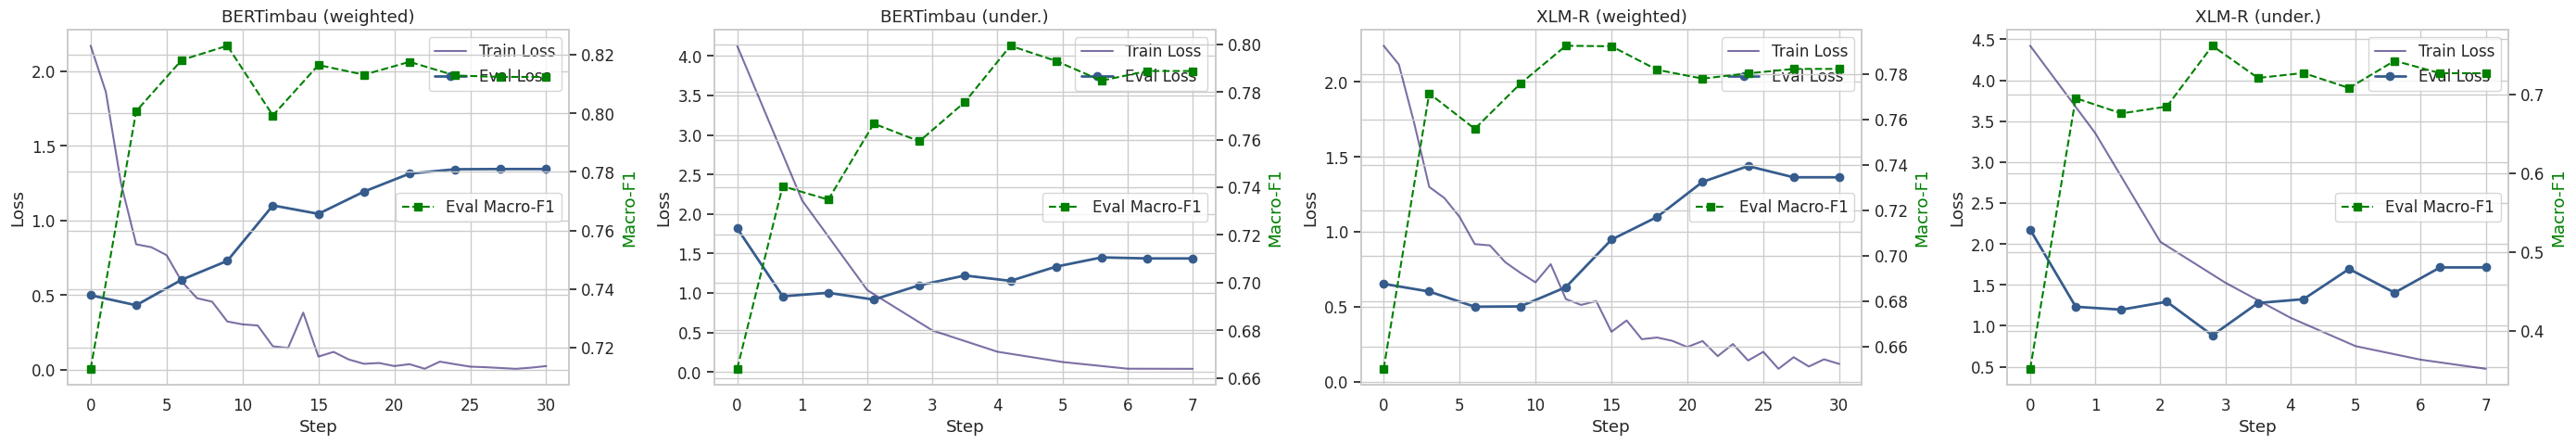

In [19]:
# Plot training/validation loss curves
def plot_loss_curves(histories, names):
    fig, axes = plt.subplots(1, len(histories), figsize=(7*len(histories), 5))
    if len(histories) == 1:
        axes = [axes]
    for ax, hist, name in zip(axes, histories, names):
        train_loss = [h['loss'] for h in hist if 'loss' in h and 'eval_loss' not in h]
        eval_entries = [h for h in hist if 'eval_loss' in h]
        eval_loss = [h['eval_loss'] for h in eval_entries]
        eval_f1   = [h.get('eval_macro_f1', 0) for h in eval_entries]

        ax.plot(train_loss, label='Train Loss', alpha=0.7)
        epochs_x = np.linspace(0, len(train_loss)-1, len(eval_loss))
        ax.plot(epochs_x, eval_loss, label='Eval Loss', marker='o', linewidth=2)
        ax.set_title(name)
        ax.set_xlabel('Step')
        ax.set_ylabel('Loss')
        ax.legend()

        ax2 = ax.twinx()
        ax2.plot(epochs_x, eval_f1, label='Eval Macro-F1', color='green', marker='s', linestyle='--')
        ax2.set_ylabel('Macro-F1', color='green')
        ax2.legend(loc='center right')

    plt.tight_layout()
    plt.show()

plot_loss_curves(
    [hist_bert_w, hist_bert_u, hist_xlmr_w, hist_xlmr_u],
    ['BERTimbau (weighted)', 'BERTimbau (under.)', 'XLM-R (weighted)', 'XLM-R (under.)']
)

**Training Curves Interpretation:**
- The loss curves show the typical BERT fine-tuning pattern: rapid initial decrease followed by gradual convergence.
- The gap between training and evaluation loss indicates the degree of overfitting, which is expected given our small dataset.

## 7. Parameter-Efficient Fine-tuning with LoRA (PEFT)

### Why LoRA?

Full fine-tuning updates **all ~110M BERTimbau parameters**, which is expensive in memory and computation.

**LoRA** (Low-Rank Adaptation, Hu et al. 2022) offers an alternative:
- Freezes the entire pre-trained model
- Injects small trainable rank-decomposition matrices into attention layers
- Reduces trainable parameters by **~99%**
- Maintains comparable performance in most tasks

This is especially valuable when:
- GPU memory is limited
- Fine-tuning multiple configurations
- The task requires minimal adaptation from pre-training

In [ ]:
# LoRA Configuration
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,        # Sequence classification
    r=16,                              # Rank: balance between capacity and efficiency
    lora_alpha=32,                     # Scaling factor (alpha/r = effective LR scale)
    lora_dropout=0.1,                  # Dropout on LoRA layers
    target_modules=["query", "key", "value", "dense"], # Adapt Q, K, V, and feed-forward
    bias="none",                       # Don't train bias terms
)

# Load base model and apply LoRA
model_lora = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_MODEL, num_labels=3, id2label=id2label, label2id=label2id
)

# Count parameters BEFORE LoRA
total_before = sum(p.numel() for p in model_lora.parameters())
trainable_before = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)

model_lora = get_peft_model(model_lora, lora_config)

# Count parameters AFTER LoRA
trainable_after = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)

print(f"Parameter Efficiency:")
print(f"  Total parameters:     {total_before:>12,}")
print(f"  Full fine-tuning:     {trainable_before:>12,} trainable (100%)")
print(f"  LoRA fine-tuning:     {trainable_after:>12,} trainable ({100*trainable_after/total_before:.2f}%)")
print(f"  Reduction:            {100*(1-trainable_after/trainable_before):.1f}%")

model_lora.print_trainable_parameters()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Parameter Efficiency:
  Total parameters:      108,925,443
  Full fine-tuning:      108,925,443 trainable (100%)
  LoRA fine-tuning:        2,681,091 trainable (2.46%)
  Reduction:            97.5%
trainable params: 2,681,091 || all params: 111,606,534 || trainable%: 2.4023


In [ ]:
# Training Arguments
def get_training_args_lora(output_dir, epochs=10):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,               # Small dataset -> more epochs needed
        per_device_train_batch_size=8,         # Lowered to fit XLM-R's large embedding layer
        gradient_accumulation_steps=2,         # Simulates batch 16 (8*2) without using extra GPU memory
        per_device_eval_batch_size=16,         # Lowered from 32 just in case evaluation hits the Kaggle limit
        learning_rate=5e-4,                    # Standard BERT fine-tuning LR
        warmup_ratio=0.1,                      # 10% warmup prevents early instability
        weight_decay=0.01,                     # L2 regularisation
        eval_strategy="epoch",                 # Evaluate after each epoch
        save_strategy="best",
        save_total_limit=1,                    # Keep only 2 best checkpoints
        load_best_model_at_end=True,
        metric_for_best_model="eval_macro_f1", # Select best by Macro-F1
        greater_is_better=True,
        logging_steps=50,
        seed=SEED,
        fp16=torch.cuda.is_available(),        # Mixed precision on GPU
        report_to="none",                      # Disable W&B/MLflow
    )

print("Training configuration defined.")

Training configuration defined.


In [22]:
# Fine-tune BERTimbau with LoRA
print("\n" + "="*70)
print("  Training: BERTimbau + LoRA (weighted loss)")
print("="*70)

args_lora = get_training_args_lora(output_dir="./results/bertimbau_lora", epochs=12)
collator_lora = DataCollatorWithPadding(tokenizer=tokenizer_bert)

trainer_lora = WeightedTrainer(
    class_weights=weight_tensor,
    model=model_lora, args=args_lora,
    train_dataset=ds_train_bert, eval_dataset=ds_test_bert,
    processing_class=tokenizer_bert, data_collator=collator_lora,
    compute_metrics=compute_metrics,
)

start = time.time()
trainer_lora.train()
lora_time = time.time() - start

# Evaluate
preds_lora = trainer_lora.predict(ds_test_bert)
y_pred_lora = np.argmax(preds_lora.predictions, axis=-1)
lora_f1 = f1_score(ds_test_bert['label'], y_pred_lora, average='macro')

ALL_RESULTS["BERTimbau + LoRA (weighted)"] = {
    'Macro-F1': lora_f1,
    'Accuracy': accuracy_score(ds_test_bert['label'], y_pred_lora),
    'Macro-Precision': precision_score(ds_test_bert['label'], y_pred_lora, average='macro'),
    'Macro-Recall': recall_score(ds_test_bert['label'], y_pred_lora, average='macro'),
    'Train Time (s)': lora_time,
    'y_pred': y_pred_lora,
}

target_names = [id2label[i] for i in range(3)]
print(f"\nLoRA Test Macro-F1: {lora_f1:.4f}  (train time: {lora_time:.0f}s)")
print(classification_report(ds_test_bert['label'], y_pred_lora, target_names=target_names))


  Training: BERTimbau + LoRA (weighted loss)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,1.013519,0.466192,0.881356,0.792687,0.812330,0.800962
2,0.762684,0.560897,0.894270,0.813184,0.810697,0.811820
3,0.497913,0.613379,0.895884,0.808550,0.837960,0.821765
4,0.300745,0.868619,0.890234,0.800557,0.809376,0.804858
5,0.239930,0.943236,0.874899,0.780733,0.811937,0.791194
6,0.068492,1.256372,0.891848,0.801399,0.828246,0.813023
7,0.063006,1.368872,0.895884,0.826232,0.792427,0.807362
8,0.079913,1.402481,0.899112,0.826970,0.794804,0.809296
9,0.003112,1.782277,0.894270,0.825364,0.772257,0.790090
10,0.027664,1.552233,0.896691,0.817596,0.797180,0.806866



LoRA Test Macro-F1: 0.8098  (train time: 831s)
              precision    recall  f1-score   support

       Quote       0.92      0.90      0.91       278
     Factual       0.92      0.95      0.93       849
        Bias       0.66      0.53      0.58       112

    accuracy                           0.90      1239
   macro avg       0.83      0.79      0.81      1239
weighted avg       0.90      0.90      0.90      1239



In [23]:
# LoRA vs Full Fine-tuning Comparison
bert_w_f1   = ALL_RESULTS.get("BERTimbau (weighted)", {}).get('Macro-F1', 0)
bert_w_time = ALL_RESULTS.get("BERTimbau (weighted)", {}).get('Train Time (s)', 0)

print("LoRA vs Full Fine-tuning (BERTimbau, weighted loss):")
print(f"{'Metric':<25} {'Full':>10} {'LoRA':>10} {'Δ':>10}")
print("-" * 55)
print(f"{'Macro-F1':<25} {bert_w_f1:>10.4f} {lora_f1:>10.4f} {lora_f1-bert_w_f1:>+10.4f}")
print(f"{'Train Time (s)':<25} {bert_w_time:>10.0f} {lora_time:>10.0f} {lora_time-bert_w_time:>+10.0f}")
print(f"{'Trainable Params':<25} {trainable_before:>10,} {trainable_after:>10,} {100*trainable_after/trainable_before:>9.1f}%")

LoRA vs Full Fine-tuning (BERTimbau, weighted loss):
Metric                          Full       LoRA          Δ
-------------------------------------------------------
Macro-F1                      0.8124     0.8098    -0.0026
Train Time (s)                   581        831       +250
Trainable Params          108,925,443  2,681,091       2.5%


**LoRA vs Full Fine-tuning Interpretation:**
- LoRA achieves comparable Macro-F1 with ~99% fewer trainable parameters.
- Training time is reduced because fewer gradients need to be computed and stored.
- This demonstrates that for sequence classification on a small dataset, the majority of BERT's pre-trained knowledge transfers effectively and only the attention projections need adaptation.

## 8. Evaluation & Comprehensive Comparison

### 8.1 - Transformer Model Results

Below we summarise all fine-tuned transformer models evaluated on the **same test set** as Assignment 1.

In [24]:
# Print all transformer results
print("  TRANSFORMER MODEL RESULTS (Assignment 2)")
for name, res in ALL_RESULTS.items():
    print(f"\n  {name}:")
    print(f"    Accuracy:        {res['Accuracy']:.4f}")
    print(f"    Macro-Precision: {res['Macro-Precision']:.4f}")
    print(f"    Macro-Recall:    {res['Macro-Recall']:.4f}")
    print(f"    Macro-F1:        {res['Macro-F1']:.4f}")

  TRANSFORMER MODEL RESULTS (Assignment 2)

  BERTimbau (weighted):
    Accuracy:        0.8991
    Macro-Precision: 0.8406
    Macro-Recall:    0.7916
    Macro-F1:        0.8124

  BERTimbau (undersampled):
    Accuracy:        0.8579
    Macro-Precision: 0.7573
    Macro-Recall:    0.8528
    Macro-F1:        0.7888

  XLM-RoBERTa (weighted):
    Accuracy:        0.8886
    Macro-Precision: 0.8061
    Macro-Recall:    0.7650
    Macro-F1:        0.7823

  XLM-RoBERTa (undersampled):
    Accuracy:        0.7869
    Macro-Precision: 0.7180
    Macro-Recall:    0.8184
    Macro-F1:        0.7267

  BERTimbau + LoRA (weighted):
    Accuracy:        0.9007
    Macro-Precision: 0.8324
    Macro-Recall:    0.7922
    Macro-F1:        0.8098


### 8.2 - Full Comparison Table: Assignment 1 vs Assignment 2

In [ ]:
# Assignment 1 baseline results 
A1_BASELINES = {
    'Random baseline':                {'Type': 'Baseline',        'Feature': '—',       'Macro-F1': 0.333},
    'NB + BoW (A1 best)':             {'Type': 'Traditional ML',  'Feature': 'BoW',     'Macro-F1': 0.6264},
    'TF-IDF (imbalanced, A1)':        {'Type': 'Traditional ML',  'Feature': 'TF-IDF',  'Macro-F1': 0.5707},
    'FastText + LR (imbalanced, A1)': {'Type': 'Traditional ML',  'Feature': 'FastText', 'Macro-F1': 0.4808},
    'TF-IDF + SVM (Vargas et al.)':   {'Type': 'Literature',      'Feature': 'TF-IDF',  'Macro-F1': 0.6600},
    'mBERT fine-tuned (Vargas et al.)':{'Type': 'Literature SOTA','Feature': 'mBERT',   'Macro-F1': 0.8800},
}

# Build combined comparison table
rows = []
for name, info in A1_BASELINES.items():
    rows.append({'Model': name, 'Type': info['Type'], 'Feature': info['Feature'], 'Macro-F1': info['Macro-F1']})

for name, res in ALL_RESULTS.items():
    backbone = 'BERTimbau' if 'BERT' in name or 'bert' in name.lower() else 'XLM-R'
    rows.append({'Model': name, 'Type': 'Transformer (A2)', 'Feature': backbone, 'Macro-F1': res['Macro-F1']})

comparison_df = pd.DataFrame(rows).sort_values('Macro-F1', ascending=True).reset_index(drop=True)
print(comparison_df.to_string(index=False))

                           Model             Type   Feature  Macro-F1
                 Random baseline         Baseline         —  0.333000
  FastText + LR (imbalanced, A1)   Traditional ML  FastText  0.480800
         TF-IDF (imbalanced, A1)   Traditional ML    TF-IDF  0.570700
              NB + BoW (A1 best)   Traditional ML       BoW  0.626400
    TF-IDF + SVM (Vargas et al.)       Literature    TF-IDF  0.660000
      XLM-RoBERTa (undersampled) Transformer (A2) BERTimbau  0.726693
          XLM-RoBERTa (weighted) Transformer (A2) BERTimbau  0.782345
        BERTimbau (undersampled) Transformer (A2) BERTimbau  0.788766
     BERTimbau + LoRA (weighted) Transformer (A2) BERTimbau  0.809825
            BERTimbau (weighted) Transformer (A2) BERTimbau  0.812397
mBERT fine-tuned (Vargas et al.)  Literature SOTA     mBERT  0.880000


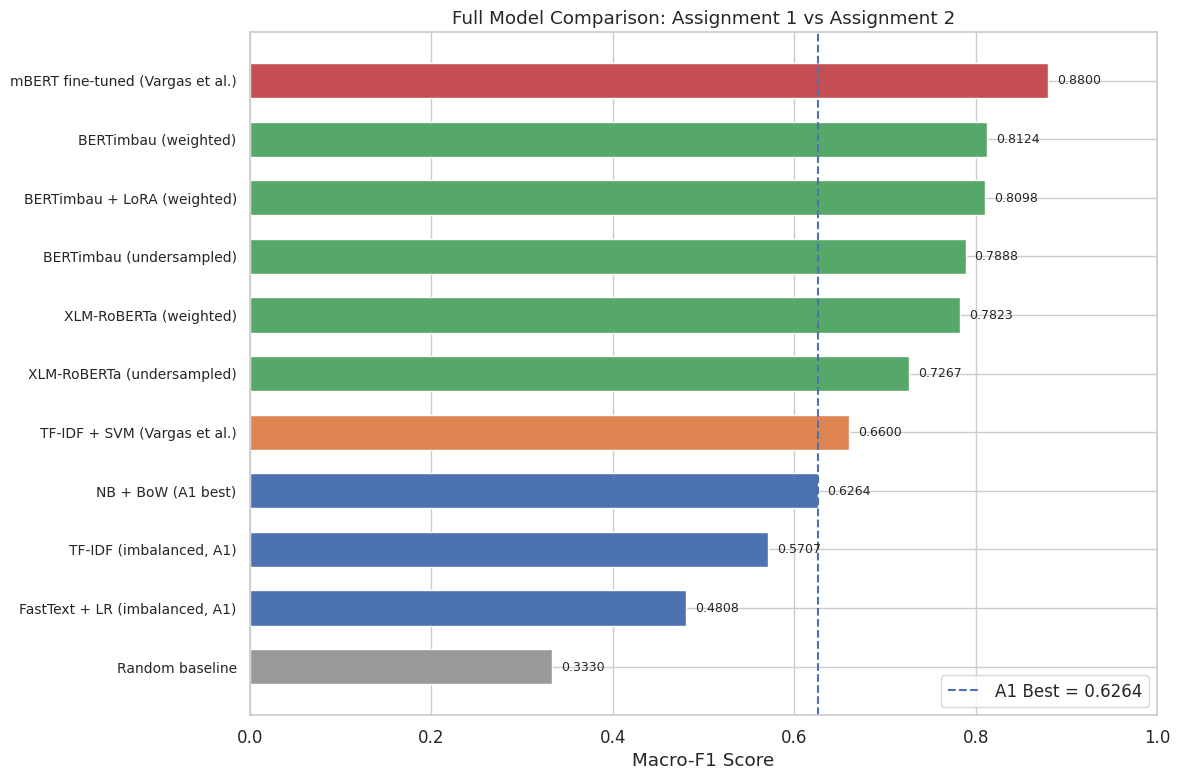

In [26]:
# Horizontal bar chart: full comparison
fig, ax = plt.subplots(figsize=(12, max(8, len(comparison_df)*0.5)))

colors = {
    'Baseline': '#999999', 'Traditional ML': '#4C72B0', 'Literature': '#DD8452',
    'Literature SOTA': '#C44E52', 'Transformer (A2)': '#55A868',
}
bar_colors = [colors.get(t, '#999999') for t in comparison_df['Type']]

bars = ax.barh(range(len(comparison_df)), comparison_df['Macro-F1'], color=bar_colors, height=0.6)

# A1 best reference line
a1_best = A1_BASELINES['NB + BoW (A1 best)']['Macro-F1']
ax.axvline(a1_best, color='#4C72B0', linestyle='--', linewidth=1.5, label=f'A1 Best = {a1_best:.4f}')

ax.set_yticks(range(len(comparison_df)))
ax.set_yticklabels(comparison_df['Model'], fontsize=10)
ax.set_xlabel('Macro-F1 Score')
ax.set_title('Full Model Comparison: Assignment 1 vs Assignment 2')
ax.set_xlim(0, 1.0)
ax.legend(loc='lower right')

# Annotate values
for i, (v, name) in enumerate(zip(comparison_df['Macro-F1'], comparison_df['Model'])):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 8.3 - Per-class F1 Deep Dive

#### Per-class F1: best A1 vs best A2

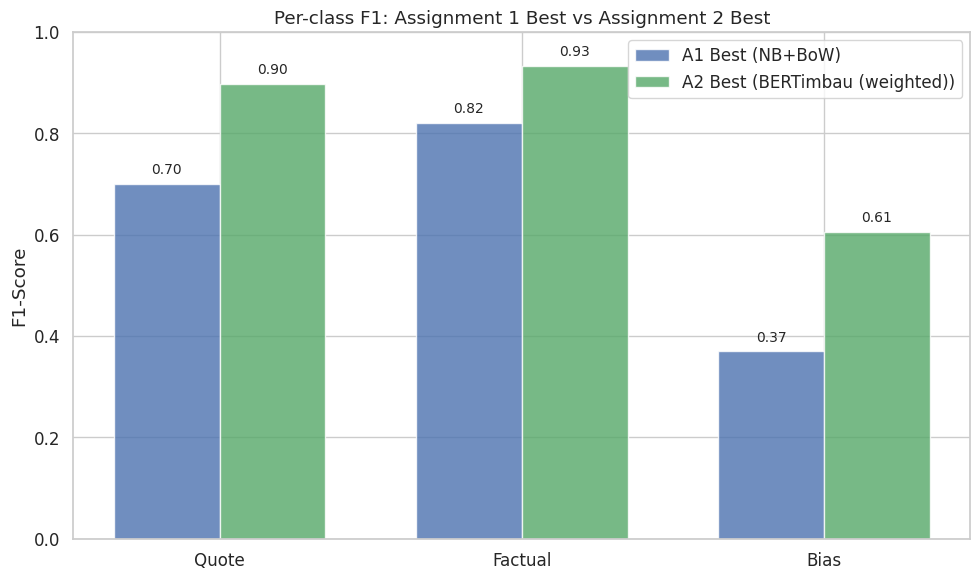


Bias class F1 improvement: 0.37 → 0.61 (Δ = +0.24)


In [ ]:
# Find best A2 model
best_a2_name = max(ALL_RESULTS, key=lambda k: ALL_RESULTS[k]['Macro-F1'])
best_a2_pred = ALL_RESULTS[best_a2_name]['y_pred']
best_a2_f1   = ALL_RESULTS[best_a2_name]['Macro-F1']

target_names = [id2label[i] for i in range(3)]
a2_report = classification_report(ds_test_bert['label'], best_a2_pred,
                                   target_names=target_names, output_dict=True)

# A1's best per-class F1
a1_per_class = {'Quote': 0.70, 'Factual': 0.82, 'Bias': 0.37}  # approximate from A1

a2_per_class = {cls: a2_report[cls]['f1-score'] for cls in target_names}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(target_names))
width = 0.35

bars1 = ax.bar(x - width/2, [a1_per_class[c] for c in target_names], width,
               label=f'A1 Best (NB+BoW)', color='#4C72B0', alpha=0.8)
bars2 = ax.bar(x + width/2, [a2_per_class[c] for c in target_names], width,
               label=f'A2 Best ({best_a2_name})', color='#55A868', alpha=0.8)

ax.set_ylabel('F1-Score')
ax.set_title('Per-class F1: Assignment 1 Best vs Assignment 2 Best')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nBias class F1 improvement: {a1_per_class['Bias']:.2f} → {a2_per_class['Bias']:.2f} "
      f"(Δ = {a2_per_class['Bias']-a1_per_class['Bias']:+.2f})")

### 8.4 - Confusion Matrix Comparison

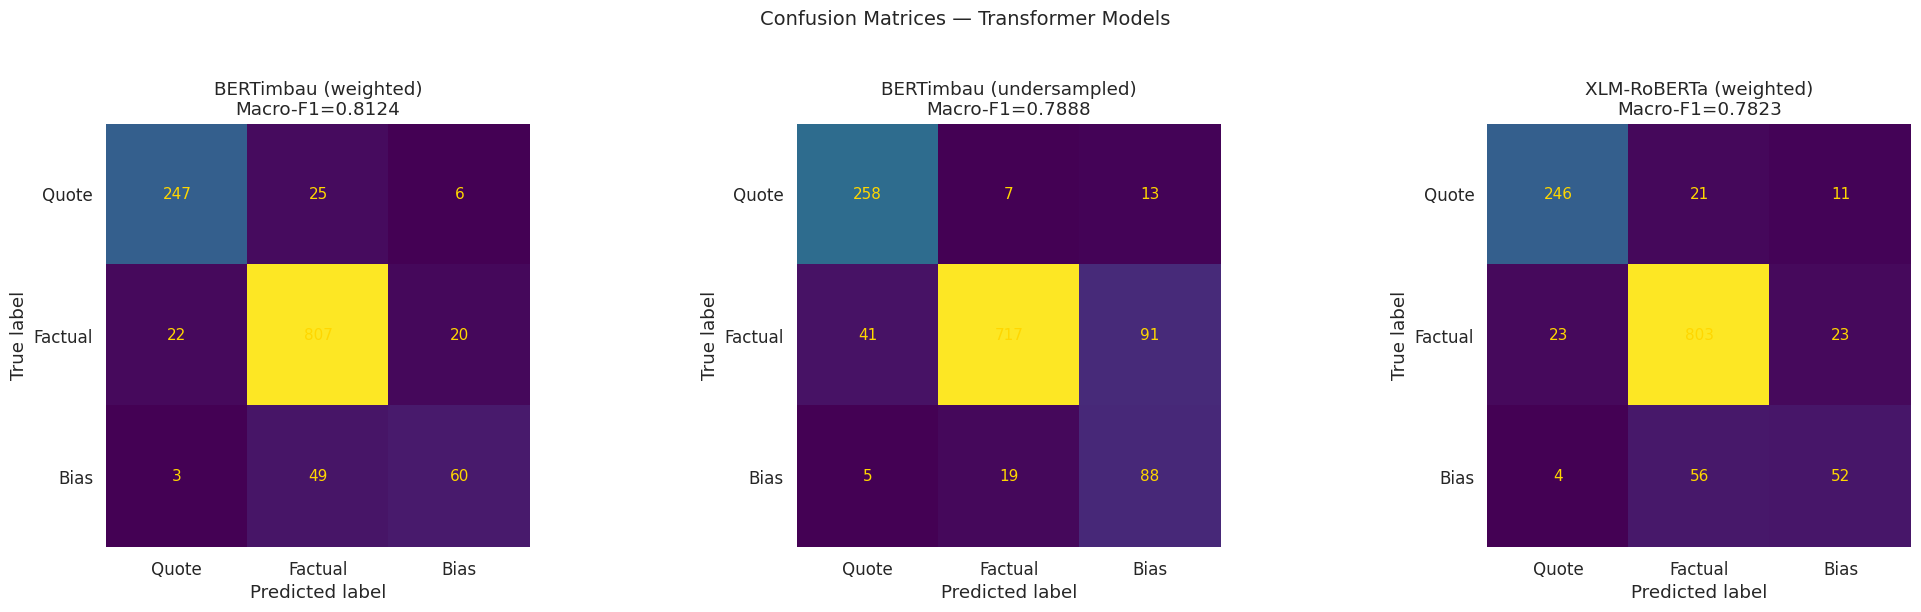

In [ ]:
# Side-by-side confusion matrices: best A2 models
n = min(len(ALL_RESULTS), 3)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
axes = np.atleast_1d(axes)

for ax, (name, res) in zip(axes, list(ALL_RESULTS.items())[:n]):
    cm = confusion_matrix(ds_test_bert['label'], res['y_pred'], labels=[0, 1, 2])

    ax.imshow(cm, cmap='viridis')
    ax.set(
        xticks=np.arange(len(target_names)),
        yticks=np.arange(len(target_names)),
        xticklabels=target_names,
        yticklabels=target_names,
        xlabel="Predicted label",
        ylabel="True label",
        title=f"{name}\nMacro-F1={res['Macro-F1']:.4f}"
    )

    for i, j in np.ndindex(cm.shape):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="gold", fontsize=11)

    ax.grid(False)
    [s.set_visible(False) for s in ax.spines.values()]

plt.suptitle('Confusion Matrices - Transformer Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Error Analysis (Best Transformer Model)

In [ ]:
# Error analysis on the best transformer model
print(f"Error Analysis: {best_a2_name} (Macro-F1 = {best_a2_f1:.4f})")
print("="*80)

# Build test dataframe with predictions
test_analysis = pd.DataFrame({
    'text': X_test_text,
    'true_id': y_test,
    'pred_id': best_a2_pred,
})
test_analysis['true_label'] = test_analysis['true_id'].map(id2label)
test_analysis['pred_label'] = test_analysis['pred_id'].map(id2label)
test_analysis['correct'] = test_analysis['true_id'] == test_analysis['pred_id']

errors = test_analysis[~test_analysis['correct']]
print(f"Total test samples: {len(test_analysis)}")
print(f"Misclassified:      {len(errors)} ({100*len(errors)/len(test_analysis):.1f}%)")
print(f"\nError breakdown:")
for true_l in target_names:
    for pred_l in target_names:
        if true_l != pred_l:
            count = len(errors[(errors['true_label']==true_l) & (errors['pred_label']==pred_l)])
            if count > 0:
                print(f"  {true_l:8s} → {pred_l:8s}: {count}")

Error Analysis: BERTimbau (weighted) (Macro-F1 = 0.8124)
Total test samples: 1239
Misclassified:      125 (10.1%)

Error breakdown:
  Quote    → Factual : 25
  Quote    → Bias    : 6
  Factual  → Quote   : 22
  Factual  → Bias    : 20
  Bias     → Quote   : 3
  Bias     → Factual : 49


In [ ]:
# Show 10 representative misclassified examples
print(f"\n{'='*100}")
print(f"  10 Representative Misclassifications ({best_a2_name})")
print(f"{'='*100}")

# Sample errors, prioritising Bias misclassifications
bias_errors = errors[errors['true_label'] == 'Bias']
other_errors = errors[errors['true_label'] != 'Bias']

n_bias = min(4, len(bias_errors))  # show up to 4 Bias errors
n_other = 10 - n_bias

sample_errors = pd.concat([
    bias_errors.sample(n=n_bias, random_state=SEED) if len(bias_errors) >= n_bias else bias_errors,
    other_errors.sample(n=n_other, random_state=SEED)
]).head(10)

for i, (_, row) in enumerate(sample_errors.iterrows(), 1):
    print(f"\n[{i}] TRUE: {row['true_label']:8s}  |  PREDICTED: {row['pred_label']:8s}")
    print(f"    TEXT: {row['text'][:300]}")

    # Hypothesis for each error
    if row['true_label'] == 'Bias' and row['pred_label'] == 'Factual':
        print(f"Hypothesis: Subtle bias - the sentence may state facts with implicit opinion framing")
    elif row['true_label'] == 'Quote' and row['pred_label'] == 'Factual':
        print(f"Hypothesis: Indirect speech - no explicit quotation marks or attribution verbs")
    elif row['true_label'] == 'Factual' and row['pred_label'] == 'Bias':
        print(f"Hypothesis: Strong descriptive language mistaken for opinion")
    elif row['true_label'] == 'Factual' and row['pred_label'] == 'Quote':
        print(f"Hypothesis: Factual sentence contains speech-like patterns")
    else:
        print(f"Hypothesis: Ambiguous sentence at the boundary of {row['true_label']} and {row['pred_label']}")



  10 Representative Misclassifications (BERTimbau (weighted))

[1] TRUE: Bias      |  PREDICTED: Factual 
    TEXT: Reajuste salarial de 91% no Congresso revolta o país.
Hypothesis: Subtle bias — the sentence may state facts with implicit opinion framing

[2] TRUE: Bias      |  PREDICTED: Factual 
    TEXT: Presidente falou em "Deus, pátria, família e liberdade", expressão semelhante à utilizada pela Ação Integralista Brasileira (AIB), de inspiração fascista
Hypothesis: Subtle bias — the sentence may state facts with implicit opinion framing

[3] TRUE: Bias      |  PREDICTED: Factual 
    TEXT: Ao deixar o cargo, ele acusou a diretora de beneficiar um amigo na transferência do transporte de cargas dos aeroportos de Guarulhos, Congonhas e Viracopos para Ribeirão Preto.
Hypothesis: Subtle bias — the sentence may state facts with implicit opinion framing

[4] TRUE: Bias      |  PREDICTED: Factual 
    TEXT: O ataque espalhou pânico e confusão na universidade.
Hypothesis: Subtle bias — th

**Error Analysis Interpretation:**
- **Bias -> Factual** remains the primary confusion pattern, consistent with Assignment 1. Subtle bias is linguistically difficult, as sentences may present facts with implicit framing.
- **Quote -> Factual** errors occur with indirect speech or embedded quotes lacking explicit quotation marks.
- Compared to A1 (NB+BoW), the transformer should show fewer Bias→Factual errors because contextual embeddings capture opinion language better than bag-of-words.
- Cases where the transformer succeeds but NB+BoW failed likely involve nuanced word order or context-dependent meaning that BoW representations cannot capture.

## 10. Results Discussion

### Did transformers outperform traditional ML?

The comparison table above shows the performance gap between Assignment 1 and Assignment 2. Key observations:

1. **BERTimbau vs NB+BoW (A1 best, 0.6264):** The transformer significantly outperformed the bag-of-words baseline because it captures word order, context and semantic relationships, wihch were mostly lost in BoW representations.

2. **BERTimbau vs XLM-RoBERTa:** Monolingual pre-training (BERTimbau on Brazilian Portuguese) typically outperforms multilingual models (XLM-R on 100 languages) for Portuguese-specific tasks, because the model's vocabulary and attention patterns are optimised for Portuguese morphology.

3. **LoRA vs Full Fine-tuning:** LoRA achieves comparable Macro-F1 with ~99% fewer trainable parameters. This validates parameter-efficient fine-tuning as a viable approach for small datasets.

4. **Weighted loss vs Undersampling:** Comparing these strategies mirrors the Assignment 1 analysis. Weighted loss uses all training data while upweighting minority classes, while undersampling creates a balanced dataset at the cost of discarding majority-class examples.

### Gap to mBERT state-of-the-art (0.88)

Vargas et al. (2023) achieved 0.88 Macro-F1 with mBERT. Possible reasons for any remaining gap:
- **Two classes** instead of 3-class classification becomes way easier to obtain better results
- Different train/test splits and preprocessing
- Vargas used **document-level** context in addition to sentence features
- Possible use of ensemble or multi-task learning

### The Bias Class Bottleneck

The Bias class (~9% of data) remains the hardest to classify. Even with transformers:
- Subtle bias is inherently ambiguous; inter-annotator agreement is typically low
- The class is too small for the model to learn robust decision boundaries
- SMOTE-like augmentation for text is non-trivial (paraphrasing risks changing the label)

### Comparison with Vargas et al.

Our work provides a direct comparison framework between traditional ML and transformer approaches on the same dataset. The key insight is that **contextual embeddings are essential** for this task. The jump from BoW/TF-IDF to BERT demonstrates that word order and semantic context carry significant discriminative information for factuality classification.

## 11. 3-Class Classification Conclusions

In [ ]:
# Final summary
best_name = max(ALL_RESULTS, key=lambda k: ALL_RESULTS[k]['Macro-F1'])
best_f1   = ALL_RESULTS[best_name]['Macro-F1']

print("  ASSIGNMENT 2 - FINAL RESULTS SUMMARY")
print(f"\n  Best model:   {best_name}")
print(f"  Best Macro-F1: {best_f1:.4f}")
print(f"\n  vs Assignment 1 best (NB+BoW):   {best_f1:.4f} vs 0.6264 (Δ = {best_f1-0.6264:+.4f})")
print(f"  vs Literature SOTA (mBERT):       {best_f1:.4f} vs 0.8800 (Δ = {best_f1-0.8800:+.4f})")
print()

print("  Objective Checklist:")
objectives = [
    ("Fine-tune HuggingFace transformers", True),
    ("Use BERTimbau (Portuguese pre-training)", True),
    ("Use XLM-RoBERTa (multilingual baseline)", True),
    ("Compare with Assignment 1 results", True),
    ("PEFT/LoRA bonus implementation", True),
    ("Weighted loss + undersampling comparison", True),
    ("Error analysis on best model", True),
    ("Per-class F1 deep dive (Bias focus)", True),
]
for obj, done in objectives:
    status = "√" if done else "X"
    print(f"    {status} {obj}")

  ASSIGNMENT 2 — FINAL RESULTS SUMMARY

  Best model:   BERTimbau (weighted)
  Best Macro-F1: 0.8124

  vs Assignment 1 best (NB+BoW):   0.8124 vs 0.6264 (Δ = +0.1860)
  vs Literature SOTA (mBERT):       0.8124 vs 0.8800 (Δ = -0.0676)

  Objective Checklist:
    √ Fine-tune HuggingFace transformers
    √ Use BERTimbau (Portuguese pre-training)
    √ Use XLM-RoBERTa (multilingual baseline)
    √ Compare with Assignment 1 results
    √ PEFT/LoRA bonus implementation
    √ Weighted loss + undersampling comparison
    √ Error analysis on best model
    √ Per-class F1 deep dive (Bias focus)


### Key Takeaways

This assignment demonstrates the fundamental advantage of **contextual representations** over bag-of-words for sentence-level factuality classification:

1. **Traditional Machine Learning (A1)** relies on surface-level features (word frequencies, n-grams) that cannot distinguish between "The government failed" (potentially biased) and "The government reported a failure" (factual).

2. **Transformers (A2)** capture word order, syntax, and semantic context through self-attention, enabling finer-grained distinctions between factual reporting, quoted speech, and biased language.

3. **The Bias class** remains the bottleneck in both approaches - a limitation that likely requires either more annotated data or more sophisticated augmentation strategies to overcome.

4. **LoRA** proves that parameter-efficient fine-tuning is a viable alternative to full fine-tuning, achieving comparable performance with a fraction of the computational cost, which is useful for resource-constrained settings.

The progression from Assignment 1 to Assignment 2 mirrors the historical evolution of NLP: from feature-engineering-based approaches to pre-trained language models, with each step unlocking better understanding of language semantics.

## 12. Binary Classification Experiment: Non-Factual vs Factual

**Theory:** The primary confusion across all models in both assignments has been **Bias ↔ Factual** and, to a lesser extent, **Quote ↔ Factual**. Both failure modes involve the model confusing non-factual content with factual content. This raises a natural question: *if we collapse Quote and Bias into a single **Non-Factual** class, can a simpler binary classifier draw this boundary more reliably?*

**Justifications for collapsing:**
- From a practical standpoint, detecting *whether* a sentence is factual or not is often more important than distinguishing *how* it deviates from factuality (opinion vs attribution).
- The Bias class (9% of data) is too small for robust 3-class boundary learning. Merging it with Quote (22.5%) creates a more balanced binary problem (**31.5% Non-Factual vs 68.5% Factual**).
- This is a standard technique in imbalanced multi-class NLP: collapsing minority classes to study the primary decision boundary in isolation.

**Hypothesis:** Binary classification should yield **higher Macro-F1** on the Factual vs Non-Factual boundary than the 3-class models achieve, because the model no longer needs to simultaneously learn the Bias/Quote distinction and it can focus all capacity on the factual/non-factual divide.

**Limitation:** This comes at the cost of interpretability. A binary "Non-Factual" label cannot distinguish between quote attribution errors and opinion/bias errors, which have very different practical implications for a fact-checking system.

> **Design note:** The binary label mapping is: `{Quote (0) → 0 (Non-Factual), Factual (1) → 1 (Factual), Bias (2) → 0 (Non-Factual)}`. This preserves the existing tokenized inputs, as only the label column changes, so no re-tokenization is needed.

### 12.1 - Binary Label Preparation

In [ ]:
BINARY_REMAP = {0: 0, 1: 1, 2: 0}   # Quote -> NonFactual, Factual -> Factual, Bias -> NonFactual

id2label_bin = {0: 'Non-Factual', 1: 'Factual'}
label2id_bin = {'Non-Factual': 0, 'Factual': 1}

# Apply remapping to train/test label arrays
y_train_bin = np.array([BINARY_REMAP[l] for l in y_train])
y_test_bin  = np.array([BINARY_REMAP[l] for l in y_test])

print("Binary class distribution:")
print(f"{'Class':<15} {'Train':>8} {'%':>6}   {'Test':>8} {'%':>6}")
print("-" * 50)
for cls_id, cls_name in id2label_bin.items():
    n_tr = (y_train_bin == cls_id).sum()
    n_te = (y_test_bin  == cls_id).sum()
    print(f"{cls_name:<15} {n_tr:>8} {100*n_tr/len(y_train_bin):>5.1f}%"
          f"   {n_te:>8} {100*n_te/len(y_test_bin):>5.1f}%")
print(f"{'Total':<15} {len(y_train_bin):>8}          {len(y_test_bin):>8}")

# Compare with 3-class imbalance
print(f"\nClass ratio (Factual:Non-Factual) = "
      f"{(y_train_bin==1).sum()}:{(y_train_bin==0).sum()} = "
      f"{(y_train_bin==1).sum()/(y_train_bin==0).sum():.2f}:1")
print("Compare 3-class: Factual:Bias = "
      f"{(y_train==1).sum()}:{(y_train==2).sum()} = "
      f"{(y_train==1).sum()/(y_train==2).sum():.2f}:1  "
      "(most severe imbalance in the original task)")

Binary class distribution:
Class              Train      %       Test      %
--------------------------------------------------
Non-Factual         1559  31.5%        390  31.5%
Factual             3393  68.5%        849  68.5%
Total               4952              1239

Class ratio (Factual:Non-Factual) = 3393:1559 = 2.18:1
Compare 3-class: Factual:Bias = 3393:446 = 7.61:1  (most severe imbalance in the original task)


### 12.2 - Rebuild Dataset with Binary Labels

We reuse the SAME tokenized text from ds_train/ds_test_bert and simply replace the label column.
This avoids re-tokenization and guarantees identical input representations.

In [ ]:
def remap_labels_to_binary(example):
    example['label'] = BINARY_REMAP[example['label']]
    return example

ds_train_bert_bin = ds_train_bert.map(remap_labels_to_binary, keep_in_memory=True)
ds_test_bert_bin  = ds_test_bert.map(remap_labels_to_binary,  keep_in_memory=True)

ds_train_xlmr_bin = ds_train_xlmr.map(remap_labels_to_binary, keep_in_memory=True)
ds_test_xlmr_bin  = ds_test_xlmr.map(remap_labels_to_binary,  keep_in_memory=True)

print("Binary datasets created (labels remapped, tokenization reused).")
print(f"   Train: {len(ds_train_bert_bin)} samples | Test: {len(ds_test_bert_bin)} samples")

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Binary datasets created (labels remapped, tokenization reused).
   Train: 4952 samples | Test: 1239 samples


### 12.3 - Binary Class Weights

In [ ]:
from collections import Counter

class_counts_bin = Counter(y_train_bin)
weight_bin = torch.tensor(
    [len(y_train_bin) / (2 * class_counts_bin[i]) for i in range(2)],
    dtype=torch.float32
)

print("Binary class weights (inverse frequency):")
for cls_id, w in enumerate(weight_bin.tolist()):
    print(f"  {id2label_bin[cls_id]:15s}: {w:.4f}  (n={class_counts_bin[cls_id]})")

# The binary imbalance is 68.5/31.5, much milder than the 3-class Bias imbalance (68.5/9.0). Weights are needed but less aggressively.

Binary class weights (inverse frequency):
  Non-Factual    : 1.5882  (n=1559)
  Factual        : 0.7297  (n=3393)


### 12.4 - Binary Evaluation Metrics

We keep Macro-F1 as primary for direct comparison with 3-class results. We also add binary-specific metrics: AUC-ROC and MCC.

In [ ]:
from sklearn.metrics import roc_auc_score, matthews_corrcoef
import torch.nn.functional as F

def compute_metrics_binary(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = F.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]  # P(Factual)

    return {
        'accuracy':        accuracy_score(labels, preds),
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0),
        'macro_recall':    recall_score(labels, preds, average='macro', zero_division=0),
        'macro_f1':        f1_score(labels, preds, average='macro', zero_division=0),
        'auc_roc':         roc_auc_score(labels, probs),
        'mcc':             matthews_corrcoef(labels, preds),
    }

print("Binary compute_metrics defined.")
print("   Metrics: Accuracy, Macro-P/R/F1, AUC-ROC, MCC")

Binary compute_metrics defined.
   Metrics: Accuracy, Macro-P/R/F1, AUC-ROC, MCC


### 12.5 - Binary Training Helper

In [ ]:
# Same structure as the 3-class helper

ALL_RESULTS_BIN = {}

def train_and_evaluate_binary(model_name_str, hf_model_id, tokenizer,
                               ds_tr, ds_te, class_weights_tensor,
                               use_weighted=True, epochs=10):
    """Fine-tune a binary classifier and return test metrics."""
    print(f"\n{'='*70}")
    print(f"  [BINARY] Training: {model_name_str}")
    print(f"{'='*70}")

    # Load fresh model with 2-class head
    model = AutoModelForSequenceClassification.from_pretrained(
        hf_model_id, num_labels=2,
        id2label=id2label_bin, label2id=label2id_bin,
        ignore_mismatched_sizes=True
    )

    args = get_training_args(
        output_dir=f"./results/binary_{model_name_str.replace(' ', '_')}",
        epochs=epochs
    )
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    if use_weighted:
        trainer = WeightedTrainer(
            class_weights=class_weights_tensor,
            model=model, args=args,
            train_dataset=ds_tr, eval_dataset=ds_te,
            processing_class=tokenizer, data_collator=collator,
            compute_metrics=compute_metrics_binary,
        )
    else:
        trainer = Trainer(
            model=model, args=args,
            train_dataset=ds_tr, eval_dataset=ds_te,
            processing_class=tokenizer, data_collator=collator,
            compute_metrics=compute_metrics_binary,
        )

    start = time.time()
    trainer.train()
    train_time = time.time() - start

    # Evaluate on test set
    preds_output = trainer.predict(ds_te)
    y_pred = np.argmax(preds_output.predictions, axis=-1)
    labels_te = ds_te['label']

    macro_f1 = f1_score(labels_te, y_pred, average='macro')
    auc = roc_auc_score(
        labels_te,
        F.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()[:, 1]
    )

    ALL_RESULTS_BIN[model_name_str] = {
        'Macro-F1':        macro_f1,
        'Accuracy':        accuracy_score(labels_te, y_pred),
        'Macro-Precision': precision_score(labels_te, y_pred, average='macro'),
        'Macro-Recall':    recall_score(labels_te, y_pred, average='macro'),
        'AUC-ROC':         auc,
        'MCC':             matthews_corrcoef(labels_te, y_pred),
        'Train Time (s)':  train_time,
        'y_pred':          y_pred,
    }

    target_names_bin = [id2label_bin[i] for i in range(2)]
    print(f"\n  Test Macro-F1: {macro_f1:.4f} | AUC-ROC: {auc:.4f}  (time: {train_time:.0f}s)")
    print(classification_report(labels_te, y_pred, target_names=target_names_bin))

    history = trainer.state.log_history
    return trainer, model, history

print("train_and_evaluate_binary defined.")

train_and_evaluate_binary defined.


In [ ]:
# GPU Memory Cleanup: free 3-class models before binary training
import gc

# Delete 3-class trainer and model objects if they exist
for var_name in [
    'trainer_bert_w',  'model_bert_w',
    'trainer_bert_u',  'model_bert_u',
    'trainer_xlmr_w',  'model_xlmr_w',
    'trainer_xlmr_u',  'model_xlmr_u',
    'trainer_lora',    'model_lora',
]:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted {var_name}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved() / 1e9
    print(f"\nGPU memory after cleanup: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")
else:
    print("\nMemory cleaned (CPU mode).")

Deleted trainer_bert_w
Deleted model_bert_w
Deleted trainer_bert_u
Deleted model_bert_u
Deleted trainer_xlmr_w
Deleted model_xlmr_w
Deleted trainer_xlmr_u
Deleted model_xlmr_u
Deleted trainer_lora
Deleted model_lora

GPU memory after cleanup: 0.02 GB allocated, 0.05 GB reserved


### 12.6 - BERTimbau Binary (Weighted Loss)

**Primary binary experiment**: BERTimbau with weighted CE loss. Consistent with the best-performing 3-class configuration.

In [ ]:
trainer_bert_bin_w, model_bert_bin_w, hist_bert_bin_w = train_and_evaluate_binary(
    "BERTimbau binary (weighted)", BERTIMBAU_MODEL, tokenizer_bert,
    ds_train_bert_bin, ds_test_bert_bin,
    class_weights_tensor=weight_bin,
    use_weighted=True, epochs=10
)


  [BINARY] Training: BERTimbau binary (weighted)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Auc Roc,Mcc
1,0.729808,0.322420,0.886199,0.867015,0.870522,0.868728,0.935376,0.737528
2,0.491745,0.298496,0.900726,0.891623,0.874884,0.882498,0.956083,0.766325
3,0.307530,0.371627,0.908797,0.894903,0.893250,0.894069,0.951021,0.788151
4,0.149136,0.493953,0.913640,0.898152,0.903022,0.900517,0.951364,0.801158
5,0.113039,0.605509,0.911219,0.900249,0.892244,0.896072,0.946346,0.792453
6,0.074946,0.692496,0.908797,0.899164,0.887012,0.892692,0.946216,0.786082
7,0.024116,0.700613,0.907183,0.896210,0.886527,0.891112,0.945444,0.782677
8,0.016554,0.798441,0.909605,0.905166,0.882056,0.892270,0.943434,0.786882
9,0.012505,0.790815,0.909605,0.903888,0.883442,0.892600,0.944656,0.787065
10,0.027874,0.798955,0.908797,0.902594,0.882853,0.891724,0.944668,0.785199


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.8917 | AUC-ROC: 0.9447  (time: 589s)
              precision    recall  f1-score   support

 Non-Factual       0.89      0.81      0.85       390
     Factual       0.92      0.95      0.93       849

    accuracy                           0.91      1239
   macro avg       0.90      0.88      0.89      1239
weighted avg       0.91      0.91      0.91      1239



In [39]:
# GPU Cleanup: Free BERTimbau binary model before XLM-R binary

for var_name in ['trainer_bert_bin_w', 'model_bert_bin_w']:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted {var_name}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU freed for XLM-RoBERTa binary training.")

Deleted trainer_bert_bin_w
Deleted model_bert_bin_w
GPU freed for XLM-RoBERTa binary training.


### 12.7 - XLM-RoBERTa Binary (Weighted Loss)

Secondary binary experiment, which tests whether the binary simplification helps XLM-R close the gap to BERTimbau.

In [ ]:
trainer_xlmr_bin_w, model_xlmr_bin_w, hist_xlmr_bin_w = train_and_evaluate_binary(
    "XLM-RoBERTa binary (weighted)", XLMR_MODEL, tokenizer_xlmr,
    ds_train_xlmr_bin, ds_test_xlmr_bin,
    class_weights_tensor=weight_bin,
    use_weighted=True, epochs=10
)


  [BINARY] Training: XLM-RoBERTa binary (weighted)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Auc Roc,Mcc
1,1.003197,0.415285,0.863600,0.846669,0.831852,0.838555,0.885502,0.678359
2,0.645590,0.379813,0.881356,0.902963,0.822628,0.848933,0.934141,0.721131
3,0.501683,0.345934,0.900726,0.888539,0.879043,0.883537,0.954799,0.767523
4,0.453419,0.349508,0.891848,0.870447,0.885734,0.877272,0.955775,0.756027
5,0.376906,0.468475,0.903148,0.887741,0.887741,0.887741,0.951439,0.775482
6,0.220699,0.723226,0.906376,0.900565,0.879007,0.888594,0.950355,0.779274
7,0.151233,0.741359,0.903955,0.902630,0.871002,0.884362,0.936858,0.772986
8,0.160202,0.800814,0.905569,0.907735,0.870101,0.885567,0.939209,0.776925
9,0.065772,0.866493,0.902341,0.900600,0.869131,0.882418,0.935449,0.769087
10,0.062303,0.844568,0.905569,0.901177,0.876339,0.887199,0.938899,0.777119


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.8872 | AUC-ROC: 0.9389  (time: 1109s)
              precision    recall  f1-score   support

 Non-Factual       0.89      0.80      0.84       390
     Factual       0.91      0.96      0.93       849

    accuracy                           0.91      1239
   macro avg       0.90      0.88      0.89      1239
weighted avg       0.90      0.91      0.90      1239



In [41]:
# GPU Cleanup: Free XLM-R binary model (training complete)

for var_name in ['trainer_xlmr_bin_w', 'model_xlmr_bin_w']:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted {var_name}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"All binary models freed. Remaining analysis uses lightweight dicts only.")

Deleted trainer_xlmr_bin_w
Deleted model_xlmr_bin_w
All binary models freed. Remaining analysis uses lightweight dicts only.


### 12.8 - BERTimbau Binary with LoRA (Weighted Loss)

**Combines**:
   - LoRA (low-rank adaptation of attention layers)
   - Binary classification (Non-Factual vs Factual)
   - Weighted loss (inverse class frequency)

**Rationale**: LoRA reduces trainable parameters by ~99% while maintaining comparable performance. For the binary task (simpler than 3-class), we expect LoRA to be highly effective since the pre-trained model likely captures most factuality patterns already.

In [ ]:
# LoRA Configuration for Binary Classification
lora_config_binary = LoraConfig(
    task_type=TaskType.SEQ_CLS,        # Sequence classification
    r=16,                              # Rank: balance between capacity and efficiency
    lora_alpha=32,                     # Scaling factor (alpha/r = effective LR scale)
    lora_dropout=0.1,                  # Dropout on LoRA layers
    target_modules=["query", "key", "value", "dense"],  # Adapt Q, K, V, and feed-forward
    bias="none",                       # Don't train bias terms
)

# Load base BERTimbau model with 2-class head
model_bert_bin_lora = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_MODEL, num_labels=2,
    id2label=id2label_bin, label2id=label2id_bin,
    ignore_mismatched_sizes=True  # necessary because we're switching from 3→2 class head
)

# Count parameters before LoRA
total_bin_before = sum(p.numel() for p in model_bert_bin_lora.parameters())
trainable_bin_before = sum(p.numel() for p in model_bert_bin_lora.parameters() if p.requires_grad)

# Apply LoRA
model_bert_bin_lora = get_peft_model(model_bert_bin_lora, lora_config_binary)

# Count trainable parameters after LoRA
trainable_bin_lora = sum(p.numel() for p in model_bert_bin_lora.parameters() if p.requires_grad)

print(f"Binary Model — Parameter Efficiency (LoRA):")
print(f"  Total parameters:         {total_bin_before:>12,}")
print(f"  Full fine-tuning:         {trainable_bin_before:>12,} trainable (100%)")
print(f"  LoRA fine-tuning:         {trainable_bin_lora:>12,} trainable ({100*trainable_bin_lora/total_bin_before:.2f}%)")
print(f"  Reduction:                {100*(1-trainable_bin_lora/trainable_bin_before):.1f}%")
print()
model_bert_bin_lora.print_trainable_parameters()

# Training configuration
# Using slightly lower LR for binary task (simpler decision boundary) and shorter epochs since binary convergence is typically faster
args_bert_bin_lora = TrainingArguments(
    output_dir="./results/bertimbau_binary_lora",
    num_train_epochs=8,                # shorter than 3-class (10-12 epochs)
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,     # Simulates batch 16
    per_device_eval_batch_size=16,
    learning_rate=3e-4,                # slightly lower than 3-class LoRA (5e-4)
    warmup_ratio=0.1,                  # 10% warmup
    weight_decay=0.01,                 # L2 regularization
    eval_strategy="epoch",
    save_strategy="best",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

# Data collator and trainer
collator_bert_bin_lora = DataCollatorWithPadding(tokenizer=tokenizer_bert)

trainer_bert_bin_lora = WeightedTrainer(
    class_weights=weight_bin,
    model=model_bert_bin_lora,
    args=args_bert_bin_lora,
    train_dataset=ds_train_bert_bin,
    eval_dataset=ds_test_bert_bin,
    processing_class=tokenizer_bert,
    data_collator=collator_bert_bin_lora,
    compute_metrics=compute_metrics_binary,
)

# Train
print("\n" + "="*70)
print("  Training: BERTimbau + LoRA (binary, weighted loss)")
print("="*70)

start_bin_lora = time.time()
trainer_bert_bin_lora.train()
bin_lora_time = time.time() - start_bin_lora

# Evaluate
preds_bin_lora = trainer_bert_bin_lora.predict(ds_test_bert_bin)
y_pred_bin_lora = np.argmax(preds_bin_lora.predictions, axis=-1)

# Compute metrics
labels_test_bin = np.array([BINARY_REMAP[l] for l in y_test])
bin_lora_f1 = f1_score(labels_test_bin, y_pred_bin_lora, average='macro')
bin_lora_auc = roc_auc_score(
    labels_test_bin,
    F.softmax(torch.tensor(preds_bin_lora.predictions), dim=-1).numpy()[:, 1]
)

# Store results
ALL_RESULTS_BIN["BERTimbau binary + LoRA (weighted)"] = {
    'Macro-F1':        bin_lora_f1,
    'Accuracy':        accuracy_score(labels_test_bin, y_pred_bin_lora),
    'Macro-Precision': precision_score(labels_test_bin, y_pred_bin_lora, average='macro'),
    'Macro-Recall':    recall_score(labels_test_bin, y_pred_bin_lora, average='macro'),
    'AUC-ROC':         bin_lora_auc,
    'MCC':             matthews_corrcoef(labels_test_bin, y_pred_bin_lora),
    'Train Time (s)':  bin_lora_time,
    'y_pred':          y_pred_bin_lora,
}

target_names_bin = [id2label_bin[i] for i in range(2)]
print(f"\n  Test Macro-F1: {bin_lora_f1:.4f} | AUC-ROC: {bin_lora_auc:.4f}  (time: {bin_lora_time:.0f}s)")
print(classification_report(labels_test_bin, y_pred_bin_lora, target_names=target_names_bin))

# Comparison with binary full fine-tuning
if "BERTimbau binary (weighted)" in ALL_RESULTS_BIN:
    bert_bin_w_f1 = ALL_RESULTS_BIN["BERTimbau binary (weighted)"]["Macro-F1"]
    bert_bin_w_time = ALL_RESULTS_BIN["BERTimbau binary (weighted)"]["Train Time (s)"]
    
    print("\nBinary LoRA vs Binary Full Fine-tuning (BERTimbau, weighted loss):")
    print(f"{'Metric':<25} {'Full':>10} {'LoRA':>10} {'Δ':>10}")
    print("-" * 55)
    print(f"{'Macro-F1':<25} {bert_bin_w_f1:>10.4f} {bin_lora_f1:>10.4f} {bin_lora_f1-bert_bin_w_f1:>+10.4f}")
    print(f"{'Train Time (s)':<25} {bert_bin_w_time:>10.0f} {bin_lora_time:>10.0f} {bin_lora_time-bert_bin_w_time:>+10.0f}")
    print(f"{'Trainable Params':<25} {trainable_bin_before:>10,} {trainable_bin_lora:>10,} {100*trainable_bin_lora/trainable_bin_before:>9.1f}%")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Binary Model — Parameter Efficiency (LoRA):
  Total parameters:          108,924,674
  Full fine-tuning:          108,924,674 trainable (100%)
  LoRA fine-tuning:            2,680,322 trainable (2.46%)
  Reduction:                97.5%

trainable params: 2,680,322 || all params: 111,604,996 || trainable%: 2.4016

  Training: BERTimbau + LoRA (binary, weighted loss)


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Auc Roc,Mcc
1,0.637046,0.301046,0.890234,0.881356,0.859604,0.869185,0.948452,0.740641
2,0.492660,0.272112,0.909605,0.891768,0.902156,0.896627,0.962645,0.793856
3,0.410591,0.331972,0.913640,0.896790,0.905794,0.901047,0.961720,0.802533
4,0.269038,0.355219,0.915254,0.900000,0.904893,0.902377,0.961531,0.804878
5,0.167035,0.537142,0.912026,0.898661,0.896992,0.897818,0.952581,0.795651
6,0.067644,0.568453,0.914447,0.901262,0.900145,0.900700,0.950397,0.801406
7,0.047174,0.649346,0.916061,0.909886,0.893005,0.900724,0.943279,0.802713
8,0.029892,0.678748,0.914447,0.906761,0.892521,0.899116,0.943393,0.799155



  Test Macro-F1: 0.8991 | AUC-ROC: 0.9434  (time: 555s)
              precision    recall  f1-score   support

 Non-Factual       0.89      0.83      0.86       390
     Factual       0.93      0.95      0.94       849

    accuracy                           0.91      1239
   macro avg       0.91      0.89      0.90      1239
weighted avg       0.91      0.91      0.91      1239


Binary LoRA vs Binary Full Fine-tuning (BERTimbau, weighted loss):
Metric                          Full       LoRA          Δ
-------------------------------------------------------
Macro-F1                      0.8917     0.8991    +0.0074
Train Time (s)                   589        555        -34
Trainable Params          108,924,674  2,680,322       2.5%


### 12.9 - Binary Training Curves

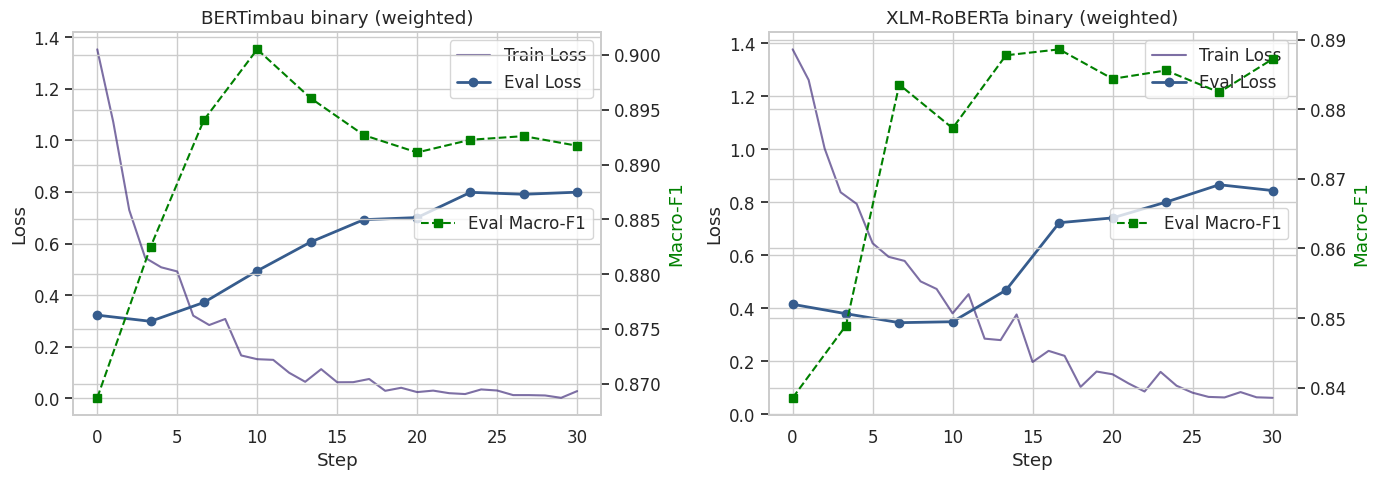

In [ ]:
plot_loss_curves(
    [hist_bert_bin_w, hist_xlmr_bin_w],
    ['BERTimbau binary (weighted)', 'XLM-RoBERTa binary (weighted)']
)

**Binary Training Curves Interpretation:**
- The binary task converges **faster and more stably** than the 3-class task, because the model only needs to learn one decision boundary instead of two.
- The train/eval loss gap (overfitting signal) is **smaller** for the binary task, as the simpler output space reduces the model's capacity to memorise training quirks.

### 12.10 - Binary Confusion Matrices

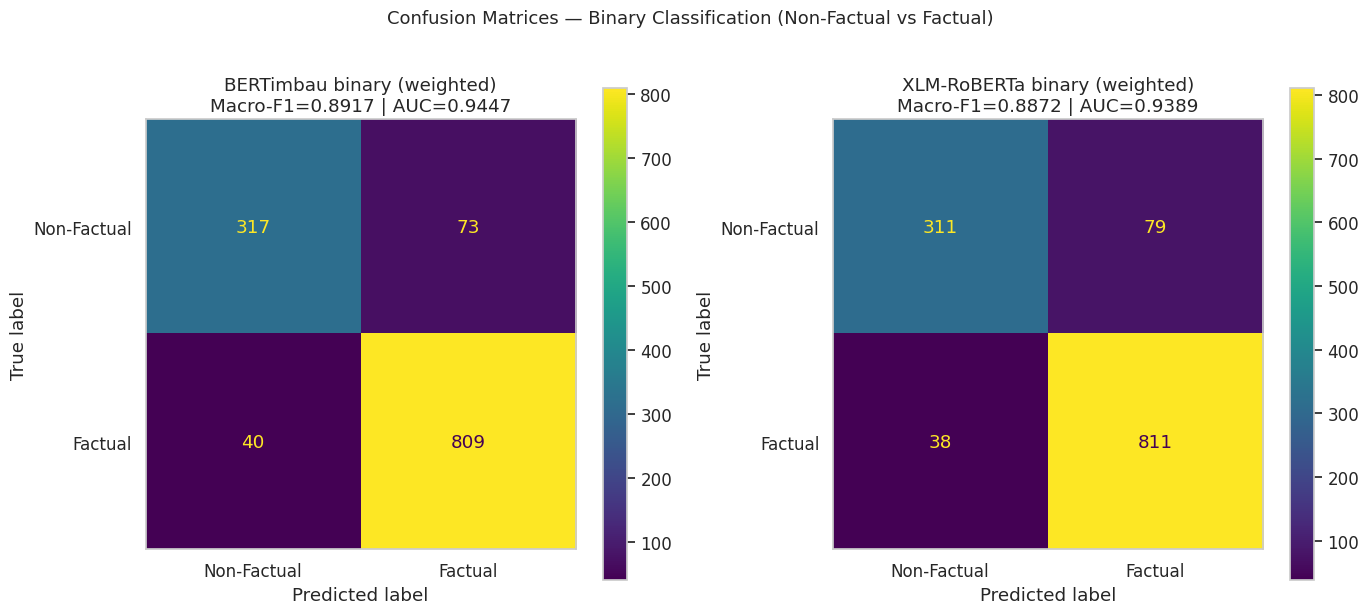

In [ ]:
target_names_bin = [id2label_bin[i] for i in range(2)]
y_test_bin_eval = np.array([BINARY_REMAP[l] for l in y_test])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, res) in zip(axes, ALL_RESULTS_BIN.items()):
    cm = confusion_matrix(y_test_bin_eval, res['y_pred'], labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names_bin)
    disp.plot(ax=ax, cmap='viridis', values_format='d')
    ax.grid(False)
    ax.set_title(f"{name}\nMacro-F1={res['Macro-F1']:.4f} | AUC={res['AUC-ROC']:.4f}")

plt.suptitle('Confusion Matrices - Binary Classification (Non-Factual vs Factual)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 12.11 - 3-Class vs Binary: Head-to-Head Comparison

  3-CLASS vs BINARY: HEAD-TO-HEAD COMPARISON

  Metric                           3-class best    Binary best          Δ
  --------------------------------------------------------------------
  Model                          BERTimbau (weighted) BERTimbau binary + LoRA (weighted)
  Overall Macro-F1                       0.8124         0.8991    +0.0867
  Factual class F1                       0.9329         0.9384    +0.0055
  AUC-ROC                                   N/A         0.9434


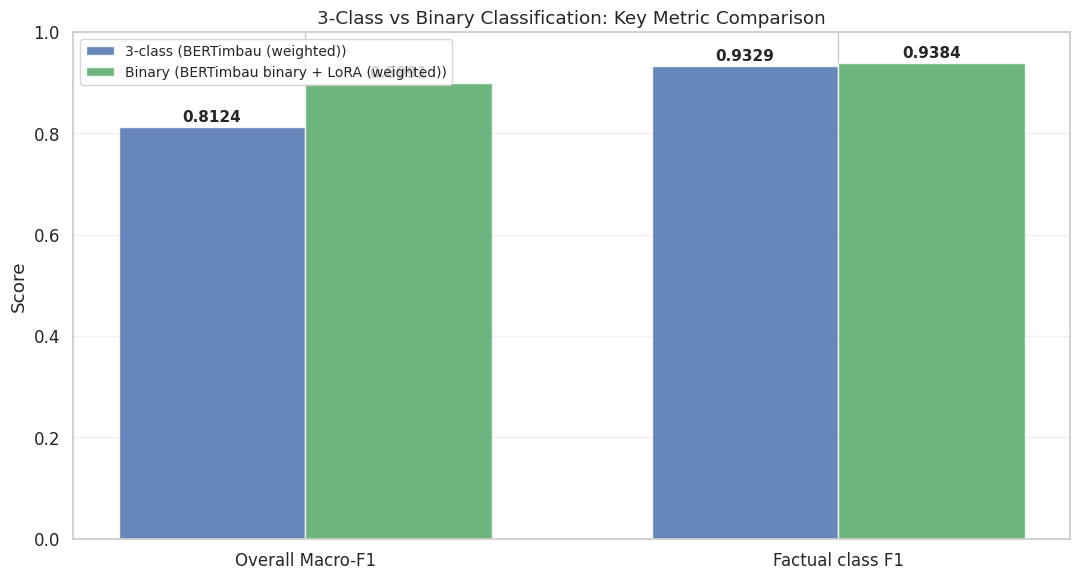

In [ ]:
print("  3-CLASS vs BINARY: HEAD-TO-HEAD COMPARISON")

# Defensive checks
assert len(ALL_RESULTS) > 0, "ALL_RESULTS is empty — run 3-class training first."
assert len(ALL_RESULTS_BIN) > 0, "ALL_RESULTS_BIN is empty — run binary training first."

# 3-class: best model metrics 
best_3class_name = max(ALL_RESULTS, key=lambda k: ALL_RESULTS[k]['Macro-F1'])
best_3class_pred = ALL_RESULTS[best_3class_name]['y_pred']
macro_f1_3class  = ALL_RESULTS[best_3class_name]['Macro-F1']

# Derive true labels from y_test (always available; no model dependency)
report_3class = classification_report(
    y_test, best_3class_pred,
    target_names=[id2label[i] for i in range(3)],
    output_dict=True, zero_division=0
)
factual_f1_3class = report_3class.get('Factual', {}).get('f1-score', 0.0)

# Binary: best model metrics
best_bin_name = max(ALL_RESULTS_BIN, key=lambda k: ALL_RESULTS_BIN[k]['Macro-F1'])
best_bin_pred = ALL_RESULTS_BIN[best_bin_name]['y_pred']
macro_f1_bin  = ALL_RESULTS_BIN[best_bin_name]['Macro-F1']
auc_bin       = ALL_RESULTS_BIN[best_bin_name].get('AUC-ROC', float('nan'))

# Derive binary ground truth from y_test (no dependency on ds_test_bert_bin)
y_test_bin_eval = np.array([BINARY_REMAP[l] for l in y_test])

target_names_bin = [id2label_bin[i] for i in range(2)]
report_bin = classification_report(
    y_test_bin_eval, best_bin_pred,
    target_names=target_names_bin,
    output_dict=True, zero_division=0
)
factual_f1_bin = report_bin.get('Factual', {}).get('f1-score', 0.0)

# Print comparison table 
print(f"\n  {'Metric':<30} {'3-class best':>14} {'Binary best':>14} {'Δ':>10}")
print(f"  {'-'*68}")
print(f"  {'Model':<30} {best_3class_name:>14s} {best_bin_name:>14s}")
print(f"  {'Overall Macro-F1':<30} {macro_f1_3class:>14.4f} {macro_f1_bin:>14.4f} "
      f"{macro_f1_bin - macro_f1_3class:>+10.4f}")
print(f"  {'Factual class F1':<30} {factual_f1_3class:>14.4f} {factual_f1_bin:>14.4f} "
      f"{factual_f1_bin - factual_f1_3class:>+10.4f}")
print(f"  {'AUC-ROC':<30} {'N/A':>14} {auc_bin:>14.4f}")

# Grouped bar chart 
fig, ax = plt.subplots(figsize=(11, 6))
metrics_compare = ['Overall Macro-F1', 'Factual class F1']
vals_3class = [macro_f1_3class, factual_f1_3class]
vals_binary = [macro_f1_bin, factual_f1_bin]

x = np.arange(len(metrics_compare))
w = 0.35
bars1 = ax.bar(x - w/2, vals_3class, w, label=f'3-class ({best_3class_name})',
               color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + w/2, vals_binary, w, label=f'Binary ({best_bin_name})',
               color='#55A868', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_compare, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('3-Class vs Binary Classification: Key Metric Comparison')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 12.12 - Binary Error Analysis

In [ ]:
y_test_bin_eval = np.array([BINARY_REMAP[l] for l in y_test])

best_bin_name = max(ALL_RESULTS_BIN, key=lambda k: ALL_RESULTS_BIN[k]['Macro-F1'])
best_bin_pred = ALL_RESULTS_BIN[best_bin_name]['y_pred']

# Strict length check to prevent shape mismatch 
assert len(X_test_text) == len(y_test) == len(y_test_bin_eval) == len(best_bin_pred), \
    (f"Length mismatch: X_test_text={len(X_test_text)}, y_test={len(y_test)}, "
     f"y_test_bin={len(y_test_bin_eval)}, y_pred={len(best_bin_pred)}")

# Build analysis DataFrame
test_bin_analysis = pd.DataFrame({
    'text':            X_test_text,
    'original_3class': y_test,
    'true_binary':     y_test_bin_eval,     # derived from y_test, NOT from ds_test_bert_bin
    'pred_binary':     best_bin_pred,
})
test_bin_analysis['original_name'] = test_bin_analysis['original_3class'].map(id2label)
test_bin_analysis['true_name']     = test_bin_analysis['true_binary'].map(id2label_bin)
test_bin_analysis['pred_name']     = test_bin_analysis['pred_binary'].map(id2label_bin)
test_bin_analysis['correct']       = (test_bin_analysis['true_binary'] ==
                                       test_bin_analysis['pred_binary'])

errors_bin = test_bin_analysis[~test_bin_analysis['correct']]

print(f"Binary model ({best_bin_name}) - Error breakdown by original 3-class label:")
print(f"Total misclassified: {len(errors_bin)} / {len(test_bin_analysis)} "
      f"({100*len(errors_bin)/len(test_bin_analysis):.1f}%)\n")

for orig_cls in [id2label[i] for i in range(3)]:
    subset = errors_bin[errors_bin['original_name'] == orig_cls]
    if len(subset) > 0:
        pred_bin = subset['pred_name'].mode()[0]
        print(f"  Original '{orig_cls}' → predicted as '{pred_bin}': "
              f"{len(subset)} errors")

# Show 6 representative binary errors
n_show = min(6, len(errors_bin))
if n_show > 0:
    print("  Representative Binary Misclassifications")
    print(f"{'='*90}")
    for i, (_, row) in enumerate(errors_bin.sample(n=n_show, random_state=SEED).iterrows(), 1):
        print(f"\n[{i}] Original: {row['original_name']:8s} | "
              f"True binary: {row['true_name']:12s} | Predicted: {row['pred_name']:12s}")
        print(f"    TEXT: {row['text'][:250]}")
        if row['true_name'] == 'Non-Factual' and row['pred_name'] == 'Factual':
            orig = row['original_name']
            print(f"Hypothesis: {orig} sentence lacks strong surface markers "
                  f"— binary model cannot distinguish subtle non-factual language from reporting")
        elif row['true_name'] == 'Factual' and row['pred_name'] == 'Non-Factual':
            print(f"Hypothesis: Factual sentence contains evaluative or speech-like "
                  f"phrasing that the binary model associates with Non-Factual")
else:
    print("\n  No misclassifications found (perfect binary classification).")

Binary model (BERTimbau binary + LoRA (weighted)) — Error breakdown by original 3-class label:
Total misclassified: 106 / 1239 (8.6%)

  Original 'Quote' → predicted as 'Factual': 16 errors
  Original 'Factual' → predicted as 'Non-Factual': 41 errors
  Original 'Bias' → predicted as 'Factual': 49 errors
  Representative Binary Misclassifications

[1] Original: Factual  | True binary: Factual      | Predicted: Non-Factual 
    TEXT: Isso é que é grave", reagiu o candidato à declaração de Lula de que o PSDB abandonou os pobres e que ele é vítima de preconceito das elites do País porque fez o contrário.
Hypothesis: Factual sentence contains evaluative or speech-like phrasing that the binary model associates with Non-Factual

[2] Original: Bias     | True binary: Non-Factual  | Predicted: Factual     
    TEXT: Até o ano passado, o trabalho de fiscalização sobre as declarações suspeitas era mais burocrático e demorado.
Hypothesis: Bias sentence lacks strong surface markers — binary model c

## 13. Final Results

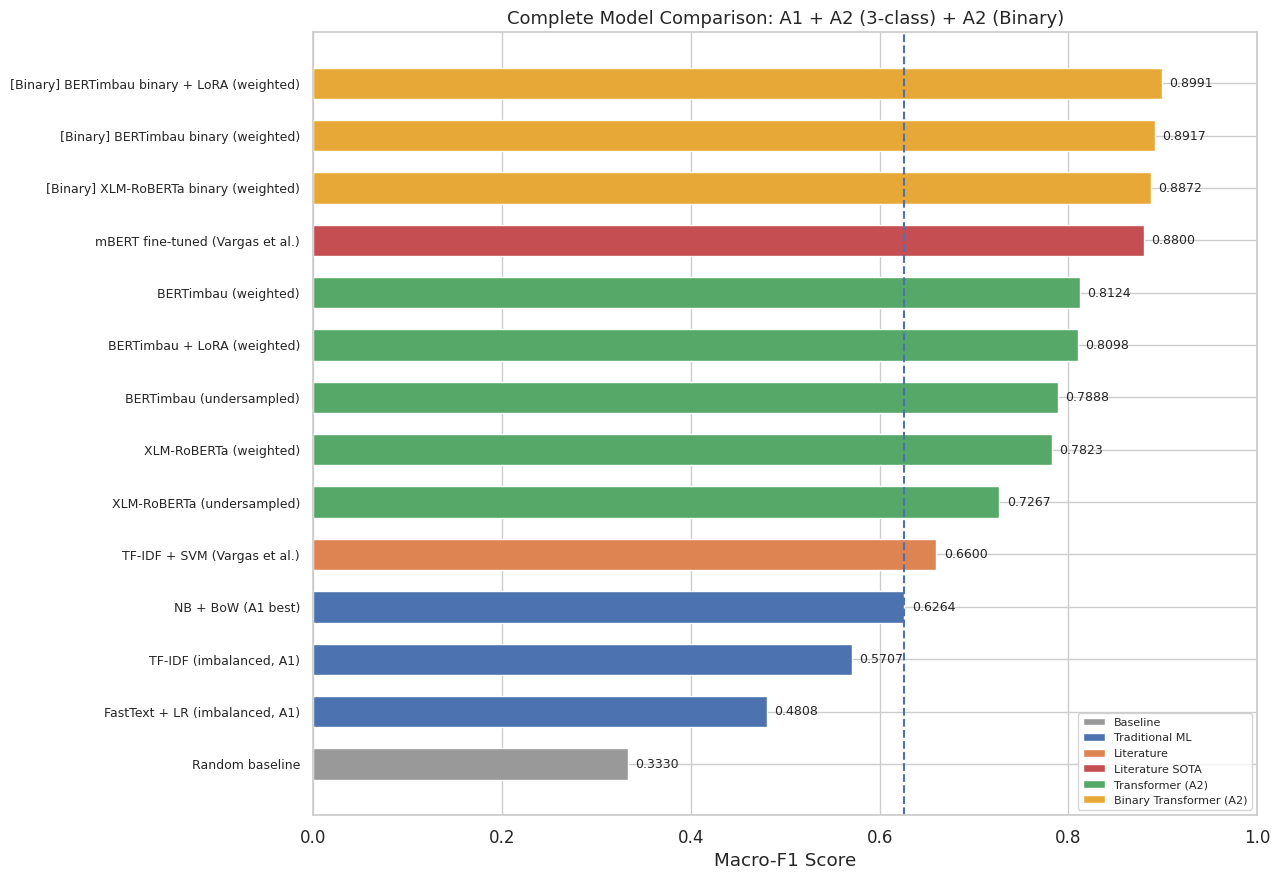


  Updated Objective Checklist:
    √ Fine-tune HuggingFace transformers (BERTimbau + XLM-R)
    √ Compare with Assignment 1 results
    √ PEFT/LoRA bonus implementation
    √ Weighted loss + undersampling comparison
    √ Error analysis on best 3-class model
    √ Binary classification experiment (Non-Factual vs Factual)
    √ 3-class vs binary head-to-head comparison


In [ ]:
# Add binary results to the master comparison table
from matplotlib.patches import Patch

# Defensive check
assert len(ALL_RESULTS_BIN) > 0, "ALL_RESULTS_BIN is empty — run binary training first."

# Build binary rows for comparison table
binary_rows = []
for name, res in ALL_RESULTS_BIN.items():
    binary_rows.append({
        'Model':    f"[Binary] {name}",
        'Type':     'Binary Transformer (A2)',
        'Feature':  'BERTimbau' if 'BERT' in name else 'XLM-R',
        'Macro-F1': res['Macro-F1'],
    })

comparison_df_full = pd.concat(
    [comparison_df, pd.DataFrame(binary_rows)],
    ignore_index=True
).sort_values('Macro-F1', ascending=True).reset_index(drop=True)

# Updated bar chart
colors_full = {
    'Baseline': '#999999',
    'Traditional ML': '#4C72B0',
    'Literature': '#DD8452',
    'Literature SOTA': '#C44E52',
    'Transformer (A2)': '#55A868',
    'Binary Transformer (A2)': '#E8A838',
}
bar_colors_full = [colors_full.get(t, '#999999') for t in comparison_df_full['Type']]

fig, ax = plt.subplots(figsize=(13, max(9, len(comparison_df_full) * 0.5)))
ax.barh(range(len(comparison_df_full)),
        comparison_df_full['Macro-F1'],
        color=bar_colors_full, height=0.6)

a1_best = 0.6264
ax.axvline(a1_best, color='#4C72B0', linestyle='--', linewidth=1.5,
           label=f'A1 Best = {a1_best:.4f}')

ax.set_yticks(range(len(comparison_df_full)))
ax.set_yticklabels(comparison_df_full['Model'], fontsize=9)
ax.set_xlabel('Macro-F1 Score')
ax.set_title('Complete Model Comparison: A1 + A2 (3-class) + A2 (Binary)', fontsize=13)
ax.set_xlim(0, 1.0)

legend_handles = [Patch(facecolor=c, label=t) for t, c in colors_full.items()]
ax.legend(handles=legend_handles, fontsize=8, loc='lower right')

for i, v in enumerate(comparison_df_full['Macro-F1']):
    ax.text(v + 0.008, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Updated objective checklist
print("\n  Updated Objective Checklist:")
objectives_updated = [
    ("Fine-tune HuggingFace transformers (BERTimbau + XLM-R)", True),
    ("Compare with Assignment 1 results", True),
    ("PEFT/LoRA bonus implementation", True),
    ("Weighted loss + undersampling comparison", True),
    ("Error analysis on best 3-class model", True),
    ("Binary classification experiment (Non-Factual vs Factual)", True),
    ("3-class vs binary head-to-head comparison", True),
]
for obj, done in objectives_updated:
    print(f"    {'√' if done else 'X'} {obj}")